# Membership Churn Analysis

## Notebook 05: Exploratory Data Analysis Part 2

---

**Author:** D. 
**Date:** March 3, 2026 
**Dataset:** churn_t_db.csv (2.1GB, 18.4M rows)

---

### Dependencies

In [0]:
# ═══════════════════════════════════════════════════════════════
# Dependencies
# ═══════════════════════════════════════════════════════════════

import sys
from datetime import datetime
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, StringType, DoubleType
from pyspark.sql.window import Window
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("Dependencies loaded successfully")

Dependencies loaded successfully


## 1.0 Setup & Configuration

### 1.1 Environment Verification

**CONTEXT**

To establish the foundational environment for Exploratory Data Analysis Part 2. This includes verifying Spark availability, confirming continued access to the Silver table produced in Notebook 02, and validating the cleaned dataset before segmentation, cohort, regional, and age band analyses begin. Notebook 05 builds directly on the temporal, distributional, and taxonomy findings established in Notebook 04.

**PURPOSE**

To ensure:
1. PySpark environment is properly initialised and consistent with previous notebooks
2. The Silver table is accessible at the expected Unity Catalog volume path
3. Visualisation libraries are confirmed available
4. Confident progression to segmentation and cohort analysis

**STEP**

Confirm that the Silver table exists at the expected path and verify PySpark and visualisation library initialisation.

In [0]:
# ═══════════════════════════════════════════════════════════════
# 1.1 Environment Verification
# ═══════════════════════════════════════════════════════════════

# Check Spark version
print(f"Spark Version    : {spark.version}")
print(f"Python Version   : {sys.version}")
print(f"Pandas Version   : {pd.__version__}")
print("-" * 70)

# Verify Silver table exists
file_info = dbutils.fs.ls("/Volumes/workspace/rcn_churn/silver/")
display(file_info)

# Confirm Silver table path
silver_path = "/Volumes/workspace/rcn_churn/silver/churn_cleaned/"
print(f"\nSilver table path: {silver_path}")

Spark Version    : 4.1.0
Python Version   : 3.12.3 (main, Jan  8 2026, 11:30:50) [GCC 13.3.0]
Pandas Version   : 2.2.3
----------------------------------------------------------------------


path,name,size,modificationTime
dbfs:/Volumes/workspace/rcn_churn/silver/churn_cleaned/,churn_cleaned/,0,1773332651801



Silver table path: /Volumes/workspace/rcn_churn/silver/churn_cleaned/


**RESULT**

Spark 4.1.0 is initialised and operational. The Silver table is accessible at `/Volumes/workspace/rcn_churn/silver/churn_cleaned/`. All visualisation libraries are confirmed available. Environment is validated and ready for exploratory analysis.

**Status:** ✓ Pass


### 1.2 Data Loading

**CONTEXT**

Notebook 05 loads directly from the Silver table produced in Notebook 02 and validated in Notebooks 03 and 04. All segmentation, cohort, and regional analyses operate on the fully cleaned and classified dataset with 14 columns, ensuring consistency with the missingness treatments, cleaning flags, and data quality exclusions established in previous notebooks. April 2022 has been formally flagged as a compromised snapshot in Notebook 04 and will be excluded from any leaver-dependent calculations throughout this notebook.


**PURPOSE**

To ensure:
1. The Silver table loads successfully with the expected row and column count
2. The 14-column schema from Notebook 02 is preserved and consistent
3. A verified baseline exists before segmentation and cohort analysis begins
4. Confident progression to the analytical sections of this notebook

**STEP**

Load the Silver table into a PySpark DataFrame and confirm row count, column count, and schema against the baseline established in Notebook 02.

In [0]:
# ═══════════════════════════════════════════════════════════════
# 1.2 Data Loading
# ═══════════════════════════════════════════════════════════════

# Define Silver table path
silver_path = "/Volumes/workspace/rcn_churn/silver/churn_cleaned/"

# Load Silver table
df = spark.read.format("delta").load(silver_path)

# Confirm row and column count
row_count = df.count()
col_count = len(df.columns)

print(f"Rows    : {row_count:,}")
print(f"Columns : {col_count}")
print("-" * 70)

# Display schema
df.printSchema()

Rows    : 18,461,480
Columns : 14
----------------------------------------------------------------------
root
 |-- _c0: integer (nullable = true)
 |-- CM_snapshot_date: date (nullable = true)
 |-- Int_nurse: string (nullable = true)
 |-- Region: string (nullable = true)
 |-- MemCategory: string (nullable = true)
 |-- CatName: string (nullable = true)
 |-- Branch: string (nullable = true)
 |-- YoB: integer (nullable = true)
 |-- MemSectorType: string (nullable = true)
 |-- YoJ: integer (nullable = true)
 |-- q_members_t: double (nullable = true)
 |-- q_leavers_t: double (nullable = true)
 |-- cleaning_flag: string (nullable = true)
 |-- geo_flag: string (nullable = true)



**RESULT**

The Silver table loaded successfully with 18,461,480 rows and 14 columns, consistent with the baseline established in Notebook 02 and confirmed in Notebooks 03 and 04. The schema is preserved as expected with all cleaning and geo flag columns present. The dataset is validated and ready for segmentation and cohort analysis.

**Status:** ✓ Pass

### 1.3 Configuration & Constants

**CONTEXT**

To centralise all notebook configuration in a single location, carrying forward the path constants, colour palette, and visualisation settings established in Notebook 04 and extending them with additional constants required for Notebook 05's segmentation, cohort, age band, and regional analyses. This includes the surge period boundaries formally defined in Notebook 04 Section 2.4, the April 2022 compromised snapshot exclusion, and age band definitions informed by the YoB distribution findings in Notebook 04 Section 3.1.


**PURPOSE**

To ensure:
1. All file paths, colour palette, and styling parameters are carried forward from Notebook 04
2. Surge period boundaries and data quality exclusions are defined as reusable constants
3. Age band boundaries are defined centrally for consistent application across all age-related analyses
4. Any future changes to configuration require a single update point

**STEP**

Define all path constants, the accessible high-contrast analytical colour palette, Matplotlib/Seaborn global styling parameters, surge period boundary dates, the April 2022 exclusion flag, and age band definitions for Notebook 05's analytical pipeline.

In [0]:
# ═══════════════════════════════════════════════════════════════
# 1.3 Configuration & Constants
# ═══════════════════════════════════════════════════════════════

# ── Paths ──────────────────────────────────────────────────────
SILVER_PATH = "/Volumes/workspace/rcn_churn/silver/churn_cleaned/"

# ── Accessible High-Contrast Analytical Colour Palette ─────────
# Selected for WCAG compliance and clarity across interactive
# and publication-quality visualisation outputs
IBM_BLUE     = "#0062FF"
IBM_ORANGE   = "#FF832B"
IBM_GREEN    = "#42BE65"
IBM_PURPLE   = "#BE95FF"
IBM_GRAY     = "#8D8D8D"
IBM_COOLBG   = "#F4F4F4"

PALETTE = [IBM_BLUE, IBM_ORANGE, IBM_GREEN, IBM_PURPLE, IBM_GRAY]

# ── Extended Palette for Multi-Segment Charts ──────────────────
IBM_TEAL     = "#009D9A"
IBM_MAGENTA  = "#EE5396"
IBM_CYAN     = "#1192E8"
IBM_GOLD     = "#B28600"

PALETTE_EXTENDED = [
    IBM_BLUE, IBM_ORANGE, IBM_GREEN, IBM_PURPLE,
    IBM_TEAL, IBM_MAGENTA, IBM_CYAN, IBM_GOLD, IBM_GRAY
]

# ── Surge Period Boundaries (from NB04 Section 2.4) ───────────
PRE_SURGE_END    = "2022-09-01"
SURGE_START      = "2022-10-01"
SURGE_END        = "2023-06-01"
POST_SURGE_START = "2023-07-01"

# ── Data Quality Exclusions ────────────────────────────────────
COMPROMISED_SNAPSHOT = "2022-04-01"
LAST_LEAVER_SNAPSHOT = "2025-11-01"

# ── Age Band Definitions ──────────────────────────────────────
# Informed by YoB distribution findings in NB04 Section 3.1
# Bands designed around career stage boundaries in nursing
AGE_BAND_LABELS = [
    "Under 25", "25-34", "35-44", "45-54", "55-64", "65+"
]
AGE_BAND_BINS = [0, 24, 34, 44, 54, 64, 200]

# ── Matplotlib Global Styling ──────────────────────────────────
plt.rcParams["figure.figsize"]    = (14, 6)
plt.rcParams["figure.facecolor"]  = IBM_COOLBG
plt.rcParams["axes.facecolor"]    = IBM_COOLBG
plt.rcParams["axes.edgecolor"]    = IBM_GRAY
plt.rcParams["axes.titlesize"]    = 14
plt.rcParams["axes.titleweight"]  = "bold"
plt.rcParams["axes.labelsize"]    = 11
plt.rcParams["xtick.labelsize"]   = 9
plt.rcParams["ytick.labelsize"]   = 9
plt.rcParams["legend.fontsize"]   = 10
plt.rcParams["grid.color"]        = IBM_GRAY
plt.rcParams["grid.alpha"]        = 0.3
plt.rcParams["grid.linestyle"]    = "--"

# ── Seaborn Global Styling ─────────────────────────────────────
sns.set_theme(style="whitegrid", palette=PALETTE)

# ── Plotly Global Template ─────────────────────────────────────
PLOTLY_TEMPLATE = "plotly_white"

# ── Run Metadata ───────────────────────────────────────────────
RUN_TS = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

print("Configuration loaded successfully")
print("-" * 70)
print(f"Silver Path           : {SILVER_PATH}")
print(f"Colour Palette        : Accessible, high-contrast analytical palette")
print(f"Extended Palette      : {len(PALETTE_EXTENDED)} colours for multi-segment charts")
print(f"Surge Period          : {SURGE_START} to {SURGE_END}")
print(f"Compromised Snapshot  : {COMPROMISED_SNAPSHOT}")
print(f"Last Leaver Snapshot  : {LAST_LEAVER_SNAPSHOT}")
print(f"Age Bands             : {AGE_BAND_LABELS}")
print(f"Run Time              : {RUN_TS}")


Configuration loaded successfully
----------------------------------------------------------------------
Silver Path           : /Volumes/workspace/rcn_churn/silver/churn_cleaned/
Colour Palette        : Accessible, high-contrast analytical palette
Extended Palette      : 9 colours for multi-segment charts
Surge Period          : 2022-10-01 to 2023-06-01
Compromised Snapshot  : 2022-04-01
Last Leaver Snapshot  : 2025-11-01
Age Bands             : ['Under 25', '25-34', '35-44', '45-54', '55-64', '65+']
Run Time              : 2026-03-12 16:24:36


**RESULT**

All configuration constants loaded successfully. Path constants, colour palette, and visualisation styling parameters are carried forward from Notebook 04. Three new constant groups are introduced for Notebook 05: surge period boundaries formalising the October 2022 to June 2023 structural break identified in Notebook 04 Section 2.4, data quality exclusion flags for the April 2022 compromised snapshot and the November 2025 last usable leaver snapshot, and age band definitions with six career-stage-aligned bands informed by the YoB distribution findings in Notebook 04 Section 3.1. An extended nine-colour palette is added for multi-segment charts where the base five-colour palette would be insufficient. All constants are centralised and ready to be referenced throughout the analytical pipeline.

**Status:** ✓ Pass

## 2.0 Segmentation Analysis

### 2.1 Membership Category Composition

**CONTEXT**

The `MemCategory` field provides the highest-level membership segmentation with three parent categories; Nurse member, Nurse Support Worker, and Student, each containing distinct subcategories validated in Notebook 04 Section 4.3. Understanding the composition and temporal evolution of these three categories is essential because all subsequent cohort, regional, and age band analyses sit within this framework. As identified in Notebook 04 Section 4.1, `Nurse Full` accounts for 78.8% of December 2025 membership. This means that any metric calculated at the total membership level will be overwhelmingly shaped by the Nurse member category, potentially masking important trends within the smaller but strategically significant Student and Nurse Support Worker populations. Analysing each category separately ensures that patterns specific to these smaller groups are visible and not hidden within the overall figures.

**PURPOSE**

To ensure:
1. The membership composition across all three parent categories is profiled and quantified at the latest snapshot
2. The temporal evolution of each category is tracked across the full observation period to identify growth, decline, or structural shifts
3. Category-level growth rates are compared to identify which segments are driving overall membership growth
4. The surge period impact is assessed at the category level to determine whether all three categories participated equally in the 2022-2023 membership surge

**STEP**

Calculate total weighted membership by `MemCategory` at the December 2025 snapshot to establish current composition. Build a monthly time series of membership by category across all 60 snapshots to show how each category has changed over time. Calculate category-level growth rates across the pre-surge, surge, and post-surge periods defined in Section 1.3. Visualise composition using a stacked area chart for temporal trends and a summary table for period-level growth comparison.

In [0]:
# ═══════════════════════════════════════════════════════════════
# 2.1 Membership Category Composition
# ═══════════════════════════════════════════════════════════════

# ── Current composition (December 2025) ────────────────────────
cat_current = df.filter(
    F.col("CM_snapshot_date") == "2025-12-01"
).groupBy("MemCategory") \
 .agg(F.sum("q_members_t").alias("total_members")) \
 .orderBy(F.col("total_members").desc()) \
 .toPandas()

cat_current["pct_share"] = (
    cat_current["total_members"] / cat_current["total_members"].sum() * 100
)

print("Membership Category Composition (December 2025):")
print("-" * 70)
print(cat_current.to_string(index=False))
print("-" * 70)
print(f"Total : {cat_current['total_members'].sum():,.2f}")

# ── Monthly time series by category ───────────────────────────
cat_trend = df.groupBy("CM_snapshot_date", "MemCategory") \
    .agg(F.sum("q_members_t").alias("total_members")) \
    .orderBy("CM_snapshot_date", "MemCategory") \
    .toPandas()

cat_trend["CM_snapshot_date"] = pd.to_datetime(cat_trend["CM_snapshot_date"])

# ── Period-level growth comparison ─────────────────────────────
print("\nCategory Growth by Period:")
print("-" * 70)

for cat in cat_current["MemCategory"].tolist():
    cat_data = cat_trend[cat_trend["MemCategory"] == cat].sort_values("CM_snapshot_date")
    
    pre_surge_start = cat_data[cat_data["CM_snapshot_date"] == "2021-01-01"]["total_members"].values[0]
    pre_surge_end   = cat_data[cat_data["CM_snapshot_date"] == PRE_SURGE_END]["total_members"].values[0]
    surge_end_val   = cat_data[cat_data["CM_snapshot_date"] == SURGE_END]["total_members"].values[0]
    post_surge_val  = cat_data[cat_data["CM_snapshot_date"] == "2025-12-01"]["total_members"].values[0]
    
    pre_growth  = ((pre_surge_end / pre_surge_start) - 1) * 100
    surge_growth = ((surge_end_val / pre_surge_end) - 1) * 100
    post_growth  = ((post_surge_val / surge_end_val) - 1) * 100
    total_growth = ((post_surge_val / pre_surge_start) - 1) * 100
    
    print(f"\n{cat}:")
    print(f"  Pre-Surge  (Jan 2021 - Sep 2022) : {pre_growth:+.2f}%")
    print(f"  Surge      (Oct 2022 - Jun 2023) : {surge_growth:+.2f}%")
    print(f"  Post-Surge (Jul 2023 - Dec 2025) : {post_growth:+.2f}%")
    print(f"  Total      (Jan 2021 - Dec 2025) : {total_growth:+.2f}%")

Membership Category Composition (December 2025):
----------------------------------------------------------------------
         MemCategory  total_members  pct_share
        Nurse member   1.528993e+06  86.147538
Nurse Support Worker   1.504394e+05   8.476156
             Student   9.542162e+04   5.376306
----------------------------------------------------------------------
Total : 1,774,854.51

Category Growth by Period:
----------------------------------------------------------------------

Nurse member:
  Pre-Surge  (Jan 2021 - Sep 2022) : +4.29%
  Surge      (Oct 2022 - Jun 2023) : +10.05%
  Post-Surge (Jul 2023 - Dec 2025) : +7.45%
  Total      (Jan 2021 - Dec 2025) : +23.33%

Nurse Support Worker:
  Pre-Surge  (Jan 2021 - Sep 2022) : +7.73%
  Surge      (Oct 2022 - Jun 2023) : +41.54%
  Post-Surge (Jul 2023 - Dec 2025) : +21.21%
  Total      (Jan 2021 - Dec 2025) : +84.83%

Student:
  Pre-Surge  (Jan 2021 - Sep 2022) : -6.22%
  Surge      (Oct 2022 - Jun 2023) : +12.81%
  Post-

In [0]:
# ═══════════════════════════════════════════════════════════════
# 2.1 Membership Category Composition - Visualisation
# ═══════════════════════════════════════════════════════════════

color_map = {
    "Nurse member": IBM_BLUE,
    "Nurse Support Worker": IBM_GREEN,
    "Student": IBM_ORANGE
}

# ── Stacked area chart: temporal composition ──────────────────
cat_pivot = cat_trend.pivot(
    index="CM_snapshot_date", columns="MemCategory", values="total_members"
).fillna(0)

fig = go.Figure()

for cat in ["Student", "Nurse Support Worker", "Nurse member"]:
    if cat in cat_pivot.columns:
        fig.add_trace(go.Scatter(
            x=cat_pivot.index,
            y=cat_pivot[cat],
            mode="lines",
            name=cat,
            stackgroup="one",
            line=dict(color=color_map[cat], width=0.5),
            hovertemplate=(
                f"<b>{cat}</b><br>"
                "%{x|%b %Y}<br>"
                "Members: %{y:,.0f}<extra></extra>"
            )
        ))

# Surge period shading
fig.add_vrect(
    x0=SURGE_START, x1=SURGE_END,
    fillcolor=IBM_GRAY, opacity=0.1,
    layer="below", line_width=0,
    annotation_text="Surge Period",
    annotation_position="top left"
)

fig.update_layout(
    title="Membership Composition by Category (Jan 2021 - Dec 2025)",
    xaxis_title="Snapshot Date",
    yaxis_title="Total Members",
    template=PLOTLY_TEMPLATE,
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
    yaxis=dict(tickformat=",.0f")
)

fig.show()

# ── Percentage share over time ─────────────────────────────────
cat_trend_total = cat_trend.groupby("CM_snapshot_date")["total_members"].sum().reset_index()
cat_trend_total.columns = ["CM_snapshot_date", "grand_total"]
cat_pct = cat_trend.merge(cat_trend_total, on="CM_snapshot_date")
cat_pct["pct_share"] = cat_pct["total_members"] / cat_pct["grand_total"] * 100

fig2 = go.Figure()

for cat in ["Student", "Nurse Support Worker", "Nurse member"]:
    cat_data = cat_pct[cat_pct["MemCategory"] == cat]
    fig2.add_trace(go.Scatter(
        x=cat_data["CM_snapshot_date"],
        y=cat_data["pct_share"],
        mode="lines",
        name=cat,
        stackgroup="one",
        line=dict(color=color_map[cat], width=0.5),
        hovertemplate=(
            f"<b>{cat}</b><br>"
            "%{x|%b %Y}<br>"
            "Share: %{y:.1f}%<extra></extra>"
        )
    ))

fig2.add_vrect(
    x0=SURGE_START, x1=SURGE_END,
    fillcolor=IBM_GRAY, opacity=0.1,
    layer="below", line_width=0
)

fig2.update_layout(
    title="Membership Category Share Over Time (%, Jan 2021 - Dec 2025)",
    xaxis_title="Snapshot Date",
    yaxis_title="Category Share (%)",
    template=PLOTLY_TEMPLATE,
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
    yaxis=dict(ticksuffix="%", range=[0, 100])
)

fig2.show()

**RESULT**

The membership composition analysis confirms that Nurse member accounts for 86.1% of total membership in December 2025, followed by Nurse Support Worker at 8.5% and Student at 5.4%. The percentage share chart shows this composition has remained broadly stable across the full observation period, with Nurse member consistently holding between 84% and 88% of total membership.

Growth rates across the three periods tell three very different stories. Nurse Support Worker is the fastest-growing category at +84.83% overall, with sustained positive growth across all three periods — not just the surge. This suggests that Nurse Support Worker growth is driven by a structural expansion in this workforce segment rather than a temporary event. Nurse member grew +23.33% overall, with the majority of that growth concentrated in the surge period (+10.05%) and a continued healthy post-surge trajectory (+7.45%). Student is the only category in overall decline at -16.96%, and notably the surge period was the only period where Student membership grew (+12.81%), bookended by pre-surge decline (-6.22%) and a steeper post-surge decline (-21.51%).

**Status:** ✓ Pass

#### 2.1.1 Student Pipeline Investigation

**CONTEXT**

The category growth analysis in Section 2.1 revealed a striking contrast: Students are the only category declining overall at -16.96%, and their only period of growth coincided with the surge. Meanwhile, Nurse Support Worker posted the strongest growth of any category at +84.83%, sustained across all three periods. Since students are not a permanent membership category as they graduate and either convert to a qualified membership category or leave the organisation, the student population functions as a pipeline feeding into the Nurse member and Nurse Support Worker categories. Understanding the timing and scale of student inflows and outflows helps determine whether the post-surge qualified category growth is partly driven by converted students, and whether the pre-surge student decline reflects a retention gap at the graduation transition point.

**PURPOSE**

To ensure:
1. The monthly pattern of student membership growth and decline is profiled to reveal intake and graduation cycles
2. The timing of student outflows is compared against qualified category inflows to identify potential conversion patterns
3. The scale of student decline is assessed relative to qualified category growth to determine whether conversion alone explains the observed trends
4. Limitations of the aggregated dataset for tracking individual member transitions are explicitly documented


**STEP**

Calculate month-over-month membership change for each of the three categories separately. Plot all three change series on a shared timeline to visually identify whether student losses coincide with qualified category gains. Calculate the ratio of student losses to qualified category gains during key transition periods. Compare the seasonal pattern of student membership change against the Q4 intake cycle and typical graduation timing established in Notebook 04 Section 2.3.

In [0]:
# ═══════════════════════════════════════════════════════════════
# 2.1.1 Student Pipeline Investigation
# ═══════════════════════════════════════════════════════════════

# ── Monthly MoM change by category ─────────────────────────────
cat_mom = cat_trend.copy()
cat_mom = cat_mom.sort_values(["MemCategory", "CM_snapshot_date"])
cat_mom["mom_change"] = cat_mom.groupby("MemCategory")["total_members"].diff()

# Print monthly changes side by side
cat_mom_pivot = cat_mom.pivot(
    index="CM_snapshot_date", columns="MemCategory", values="mom_change"
).dropna()

print("Month-over-Month Membership Change by Category:")
print("-" * 70)
print(cat_mom_pivot.to_string())

# ── Summary: months where Students declined ────────────────────
student_decline = cat_mom_pivot[cat_mom_pivot["Student"] < 0].copy()
student_decline["nurse_gain"] = student_decline["Nurse member"]
student_decline["nsw_gain"] = student_decline["Nurse Support Worker"]
student_decline["qualified_total_gain"] = (
    student_decline["nurse_gain"] + student_decline["nsw_gain"]
)

print("\n\nMonths Where Students Declined:")
print("-" * 70)
print(f"Total months with student decline : {len(student_decline)} of {len(cat_mom_pivot)}")
print(f"Average monthly student loss      : {student_decline['Student'].mean():,.0f}")
print(f"Average monthly Nurse gain        : {student_decline['nurse_gain'].mean():,.0f}")
print(f"Average monthly NSW gain          : {student_decline['nsw_gain'].mean():,.0f}")
print(f"Average combined qualified gain   : {student_decline['qualified_total_gain'].mean():,.0f}")

Month-over-Month Membership Change by Category:
----------------------------------------------------------------------
MemCategory       Nurse Support Worker  Nurse member       Student
CM_snapshot_date                                                  
2021-02-01                  947.149644   1603.325416    169.239905
2021-03-01                  454.275534    973.871734   2333.729216
2021-04-01                 1356.888361   4605.106888   1662.707838
2021-05-01                  371.140143   1036.223278    -53.444181
2021-06-01                  549.287411    852.137767    157.363420
2021-07-01                  623.515439    944.180523     -5.938242
2021-08-01                  207.838480   2627.672209   -953.087886
2021-09-01                 -264.251781   3212.589074  -1250.000000
2021-10-01                  507.719715   5216.745843   8672.802850
2021-11-01                 -154.394299  15290.973872  -9038.004751
2021-12-01                  145.486936   2259.501189   1146.080760
2022-01-01

#### 2.1.1 Student Pipeline Investigation - Visualisation

In [0]:
# ═══════════════════════════════════════════════════════════════
# 2.1.1 Student Pipeline Investigation - Visualisation
# ═══════════════════════════════════════════════════════════════

# ── Three-panel MoM change comparison ──────────────────────────
fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=(
        "Nurse Member - Month-over-Month Change",
        "Nurse Support Worker - Month-over-Month Change",
        "Student - Month-over-Month Change"
    ),
    vertical_spacing=0.08,
    shared_xaxes=True
)

categories_config = [
    ("Nurse member", IBM_BLUE, 1),
    ("Nurse Support Worker", IBM_GREEN, 2),
    ("Student", IBM_ORANGE, 3)
]

for cat, color, row in categories_config:
    cat_data = cat_mom[cat_mom["MemCategory"] == cat]
    fig.add_trace(
        go.Bar(
            x=cat_data["CM_snapshot_date"],
            y=cat_data["mom_change"],
            name=cat,
            marker_color=[
                color if v >= 0 else IBM_GRAY
                for v in cat_data["mom_change"]
            ],
            hovertemplate=(
                f"<b>{cat}</b><br>"
                "%{x|%b %Y}<br>"
                "Change: %{y:,.0f}<extra></extra>"
            )
        ),
        row=row, col=1
    )
    fig.add_hline(
        y=0, line_dash="dash", line_color=IBM_GRAY,
        line_width=0.5, row=row, col=1
    )

# Surge period shading on all panels
for row in [1, 2, 3]:
    fig.add_vrect(
        x0=SURGE_START, x1=SURGE_END,
        fillcolor=IBM_GRAY, opacity=0.1,
        layer="below", line_width=0,
        row=row, col=1
    )

fig.update_layout(
    title="Month-over-Month Membership Change by Category (Jan 2021 - Dec 2025)",
    template=PLOTLY_TEMPLATE,
    height=800,
    showlegend=False,
    hovermode="x unified"
)

fig.update_yaxes(tickformat=",.0f")
fig.update_xaxes(title_text="Snapshot Date", row=3, col=1)

fig.show()

#### 2.1.1 Student Pipeline - Seasonal Pattern by Category

Average Monthly Change by Calendar Month and Category:
----------------------------------------------------------------------
 calendar_month month_name  Nurse Support Worker  Nurse member      Student
              1        Jan           1921.021378   5221.941805 -1557.304038
              2        Feb           1755.938242   2882.422803 -1810.570071
              3        Mar           1152.019002   1880.047506   -76.009501
              4        Apr           1074.228029   3069.477435   581.947743
              5        May           1368.171021   3261.282660  -209.619952
              6        Jun            852.137767   1877.078385    -4.156770
              7        Jul            791.567696    989.311164  -669.239905
              8        Aug            956.650831   2970.902613 -1095.011876
              9        Sep            651.425178   3750.593824 -1388.954869
             10        Oct           1169.239905   6497.030879 10512.470309
             11        Nov           1

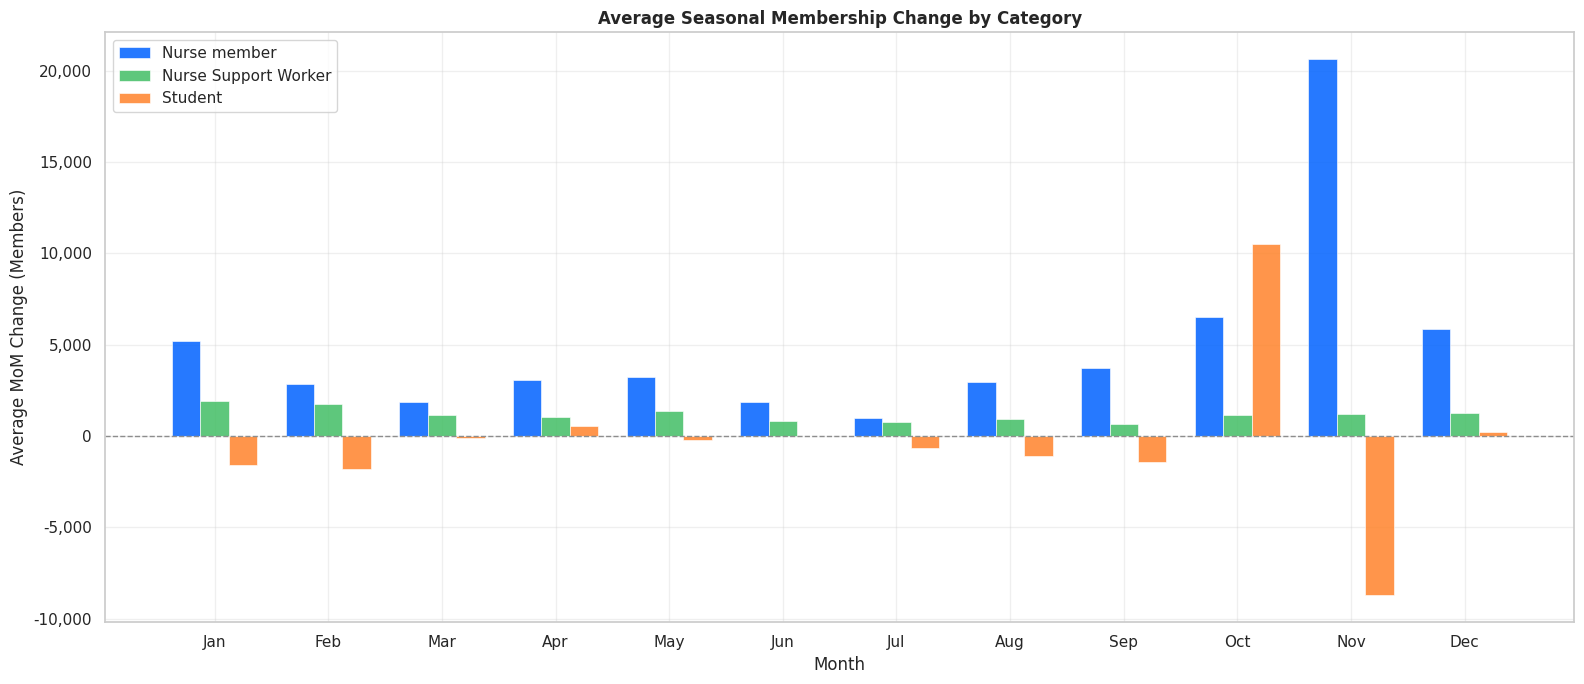

In [0]:
# ═══════════════════════════════════════════════════════════════
# 2.1.1 Student Pipeline - Seasonal Pattern by Category
# ═══════════════════════════════════════════════════════════════

# ── Average MoM change by calendar month for each category ─────
cat_mom["calendar_month"] = cat_mom["CM_snapshot_date"].dt.month
cat_mom["month_name"] = cat_mom["CM_snapshot_date"].dt.strftime("%b")

seasonal_cat = cat_mom.groupby(
    ["calendar_month", "month_name", "MemCategory"]
)["mom_change"].mean().reset_index()
seasonal_cat = seasonal_cat.sort_values(["calendar_month", "MemCategory"])

# Print seasonal pattern
print("Average Monthly Change by Calendar Month and Category:")
print("-" * 70)
seasonal_pivot = seasonal_cat.pivot(
    index=["calendar_month", "month_name"],
    columns="MemCategory",
    values="mom_change"
).reset_index()
seasonal_pivot = seasonal_pivot.sort_values("calendar_month")
print(seasonal_pivot.to_string(index=False))

# ── Grouped bar chart ──────────────────────────────────────────
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(16, 7))

x = np.arange(len(months))
width = 0.25

for i, (cat, color) in enumerate([
    ("Nurse member", IBM_BLUE),
    ("Nurse Support Worker", IBM_GREEN),
    ("Student", IBM_ORANGE)
]):
    cat_data = seasonal_cat[seasonal_cat["MemCategory"] == cat]
    cat_data = cat_data.sort_values("calendar_month")
    ax.bar(x + i * width, cat_data["mom_change"],
           width, label=cat, color=color, alpha=0.85,
           edgecolor="white", linewidth=0.5)

ax.axhline(y=0, color=IBM_GRAY, linestyle="--", linewidth=1)
ax.set_title("Average Seasonal Membership Change by Category")
ax.set_xlabel("Month")
ax.set_ylabel("Average MoM Change (Members)")
ax.set_xticks(x + width)
ax.set_xticklabels(months)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x:,.0f}"
))
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

#### 2.1.1 Student Pipeline - October-November Cycle Summary

In [0]:
# ═══════════════════════════════════════════════════════════════
# 2.1.1 Student Pipeline - October-November Cycle Summary
# ═══════════════════════════════════════════════════════════════

# ── Year-by-year October-November cycle ────────────────────────
oct_nov = cat_mom[
    cat_mom["CM_snapshot_date"].dt.month.isin([10, 11])
].copy()
oct_nov["year"] = oct_nov["CM_snapshot_date"].dt.year
oct_nov["month_label"] = oct_nov["CM_snapshot_date"].dt.strftime("%b")

cycle_pivot = oct_nov.pivot_table(
    index=["year", "month_label"],
    columns="MemCategory",
    values="mom_change"
).reset_index()

cycle_pivot = cycle_pivot.sort_values(["year", "month_label"], ascending=[True, False])

print("October-November Conversion Cycle by Year:")
print("=" * 90)
print(f"{'Year':<6} {'Month':<6} {'Student':>12} {'Nurse member':>14} {'NSW':>12} {'Qualified Total':>16}")
print("-" * 90)

for _, row in cycle_pivot.iterrows():
    student = row.get("Student", 0)
    nurse = row.get("Nurse member", 0)
    nsw = row.get("Nurse Support Worker", 0)
    qualified = nurse + nsw
    print(f"{row['year']:<6} {row['month_label']:<6} {student:>12,.0f} {nurse:>14,.0f} {nsw:>12,.0f} {qualified:>16,.0f}")

# ── Net cycle balance ──────────────────────────────────────────
print("\n\nOctober-November Net Balance by Year:")
print("=" * 90)
print(f"{'Year':<6} {'Student Net':>14} {'Nurse Net':>14} {'NSW Net':>12} {'Qualified Net':>16}")
print("-" * 90)

for year in sorted(oct_nov["year"].unique()):
    year_data = oct_nov[oct_nov["year"] == year]
    for cat in ["Student", "Nurse member", "Nurse Support Worker"]:
        cat_data = year_data[year_data["MemCategory"] == cat]
    
    student_net = year_data[year_data["MemCategory"] == "Student"]["mom_change"].sum()
    nurse_net = year_data[year_data["MemCategory"] == "Nurse member"]["mom_change"].sum()
    nsw_net = year_data[year_data["MemCategory"] == "Nurse Support Worker"]["mom_change"].sum()
    qualified_net = nurse_net + nsw_net
    
    print(f"{year:<6} {student_net:>14,.0f} {nurse_net:>14,.0f} {nsw_net:>12,.0f} {qualified_net:>16,.0f}")

October-November Conversion Cycle by Year:
Year   Month       Student   Nurse member          NSW  Qualified Total
------------------------------------------------------------------------------------------
2021   Oct           8,673          5,217          508            5,724
2021   Nov          -9,038         15,291         -154           15,137
2022   Oct          11,096          9,849        1,779           11,627
2022   Nov          -4,097         36,007        4,032           40,039
2023   Oct          11,188          5,344          941            6,286
2023   Nov         -12,583         19,225           95           19,320
2024   Oct          12,360          7,981        2,215           10,196
2024   Nov          -9,240         20,080        2,055           22,135
2025   Oct           9,246          4,094          404            4,498
2025   Nov          -8,640         12,595           30           12,625


October-November Net Balance by Year:
Year      Student Net      Nurse N

**RESULT**

The month-over-month analysis by category reveals a clear and consistent annual cycle tied to the UK nursing academic calendar. Every October shows a large student intake spike averaging +10,512 members, and every November shows a corresponding student decline averaging -8,720. At the same time, November is by far the largest single month for Nurse member growth, averaging +20,640, more than double any other month. This October-November pattern repeats in all five years of the observation period without exception.

The year-by-year summary confirms the pattern and reveals an important finding about scale. In every year, the November gains in qualified categories (Nurse member plus Nurse Support Worker combined) substantially exceed the November student losses. For example in 2023, 12,583 students left in November while qualified categories gained 19,320. Even if every departing student converted to a qualified category, student conversions would only account for roughly 65% of the qualified intake in that month. The remaining growth comes from other sources, most likely qualified nurses joining directly without ever holding student membership, nurses returning from career breaks, or nurses transferring from other professional bodies. The 2022 surge year illustrates this most clearly: only 4,097 students left in November while qualified categories gained 40,039, confirming that the industrial action surge was overwhelmingly driven by direct recruitment of already-qualified nurses rather than student conversions.

The timing of the cycle is consistent with the staggered nature of the NMC registration process. Students complete their training over the summer, but universities run their assessment boards at different times across September and October. Once results are confirmed, the university notifies the NMC, which then processes the registration and issues the professional PIN. This multi-step process means that the earliest qualifiers may receive their PIN by September or October and join directly as Nurse member, contributing to the October Nurse member growth that coincides with the student intake, while later qualifiers appear in November, December, or January as the administrative pipeline clears. The four-month window of elevated Nurse member growth from October through January (all averaging above +5,000 per month) is consistent with this staggered qualification timeline.

**Important caveat:** Because the dataset is aggregated at the cohort level, individual member transitions from Student to Nurse member cannot be directly confirmed. The findings above are based on the timing, direction, and scale of category-level membership flows, which are strongly consistent with a student-to-qualified conversion pipeline operating on the nursing academic calendar. The interpretation of the NMC registration timeline is based on the NMC registration pathway documentation.

**Status:** ✓ Pass

**SUMMARY**

Segmentation analysis reveals three membership categories on fundamentally different trajectories. Nurse Support Worker is the fastest-growing segment at +84.83% overall with sustained growth across all periods, suggesting structural expansion in this workforce tier. Nurse member grew +23.33% overall, driven primarily by the surge but maintaining healthy post-surge growth. Student is the only category in decline at -16.96%, with the surge period providing only a temporary interruption to an otherwise consistent downward trend.

The student pipeline investigation uncovered a clear and repeating October-November conversion cycle aligned to the nursing academic calendar, where student intake in October is followed by student outflow and a corresponding spike in qualified category growth in November. However, qualified category gains consistently exceed student losses in every year, confirming that the organisation's growth is primarily driven by direct recruitment of already-qualified professionals rather than the student-to-nurse conversion pipeline.

A concern for the organisation is that the student pipeline is barely sustaining itself. In 2025, the net student balance across October and November was just +606, essentially flat. Students decline in 43 of 59 months overall, losing an average of 1,986 members per month outside of the October intake window. This steady year-round attrition, students leaving without converting to a qualified category, represents a potential retention gap. Whether this pattern varies by join year cohort, age band, or region will be examined in the subsequent sections of this notebook.

**Status:** ✓ Pass


### 2.2 Sector Type Composition

**CONTEXT**

The `MemSectorType` field classifies members by their employment sector, providing a workforce context that complements the membership category segmentation in Section 2.1. As identified in Notebook 02, this field carries approximately 7.8% missing values and a known casing inconsistency. Understanding how membership is distributed across sector types, and how that distribution has changed over time, reveals whether membership growth and decline are concentrated in specific workforce settings such as the NHS, education, or independent sector. This is particularly relevant given the 2022-2023 surge period, which was driven by industrial action within the NHS specifically, and may therefore have disproportionately affected NHS sector membership.

**PURPOSE**

To ensure:
1. The membership composition across all sector types is profiled and quantified at the latest snapshot
2. The temporal evolution of each sector is tracked to identify growth, decline, or structural shifts
3. The 7.8% missing sector values are assessed for any temporal or categorical concentration
4. The surge period impact is assessed at the sector level to determine which employment settings drove the 2022-2023 membership growth

**STEP**

Calculate total weighted membership by `MemSectorType` at the December 2025 snapshot, handling the casing inconsistency by standardising values before aggregation. Build a monthly time series by sector across all 60 snapshots. Profile the missing sector values by snapshot date and membership category to determine whether missingness is random or concentrated. Compare sector-level growth rates across the pre-surge, surge, and post-surge periods.

In [0]:
# ═══════════════════════════════════════════════════════════════
# 2.2 Sector Type Composition
# ═══════════════════════════════════════════════════════════════

# ── Standardise MemSectorType casing ───────────────────────────
df = df.withColumn(
    "MemSectorType_clean",
    F.initcap(F.trim(F.col("MemSectorType")))
)

# ── Current composition (December 2025) ────────────────────────
sector_current = df.filter(
    F.col("CM_snapshot_date") == "2025-12-01"
).groupBy("MemSectorType_clean") \
 .agg(F.sum("q_members_t").alias("total_members")) \
 .orderBy(F.col("total_members").desc()) \
 .toPandas()

sector_current["pct_share"] = (
    sector_current["total_members"] / sector_current["total_members"].sum() * 100
)

print("Sector Type Composition (December 2025):")
print("-" * 70)
print(sector_current.to_string(index=False))
print("-" * 70)
print(f"Total : {sector_current['total_members'].sum():,.2f}")

# ── Missing sector profile by snapshot date ────────────────────
print("\n\nMissing Sector Type by Snapshot (first 12 and last 12):")
print("-" * 70)
missing_sector = df.groupBy("CM_snapshot_date").agg(
    F.sum(F.when(F.col("MemSectorType_clean").isNull(), F.col("q_members_t")).otherwise(0)).alias("missing_members"),
    F.sum("q_members_t").alias("total_members")
).orderBy("CM_snapshot_date").toPandas()

missing_sector["CM_snapshot_date"] = pd.to_datetime(missing_sector["CM_snapshot_date"])
missing_sector["pct_missing"] = missing_sector["missing_members"] / missing_sector["total_members"] * 100

print(missing_sector.head(12).to_string(index=False))
print("...")
print(missing_sector.tail(12).to_string(index=False))

# ── Missing sector by MemCategory ──────────────────────────────
print("\n\nMissing Sector Type by MemCategory (December 2025):")
print("-" * 70)
df.filter(
    F.col("CM_snapshot_date") == "2025-12-01"
).groupBy("MemCategory").agg(
    F.sum(F.when(F.col("MemSectorType_clean").isNull(), F.col("q_members_t")).otherwise(0)).alias("missing_members"),
    F.sum("q_members_t").alias("total_members")
).withColumn("pct_missing", F.col("missing_members") / F.col("total_members") * 100) \
 .orderBy("MemCategory") \
 .show(truncate=False)

Sector Type Composition (December 2025):
----------------------------------------------------------------------
MemSectorType_clean  total_members  pct_share
                Nhs   1.155374e+06  65.096835
        Independent   3.597506e+05  20.269300
          Education   1.651930e+05   9.307410
               None   7.782067e+04   4.384622
Other Public Sector   1.671615e+04   0.941832
----------------------------------------------------------------------
Total : 1,774,854.51


Missing Sector Type by Snapshot (first 12 and last 12):
----------------------------------------------------------------------
CM_snapshot_date  missing_members  total_members  pct_missing
      2021-01-01     76633.016627   1.436113e+06     5.336140
      2021-02-01     76517.220903   1.438833e+06     5.318005
      2021-03-01     76359.857482   1.442595e+06     5.293229
      2021-04-01     76472.684086   1.450220e+06     5.273179
      2021-05-01     76125.296912   1.451574e+06     5.244329
      2021-06-01   

In [0]:
# ═══════════════════════════════════════════════════════════════
# 2.2 Sector Type Composition - Temporal Trends
# ═══════════════════════════════════════════════════════════════

# ── Monthly time series by sector (top sectors only) ───────────
sector_trend = df.filter(
    F.col("MemSectorType_clean").isNotNull()
).groupBy("CM_snapshot_date", "MemSectorType_clean") \
 .agg(F.sum("q_members_t").alias("total_members")) \
 .orderBy("CM_snapshot_date", "MemSectorType_clean") \
 .toPandas()

sector_trend["CM_snapshot_date"] = pd.to_datetime(sector_trend["CM_snapshot_date"])

# Identify top sectors by December 2025 membership
top_sectors = sector_current[
    sector_current["MemSectorType_clean"].notna()
].head(6)["MemSectorType_clean"].tolist()

# ── Period growth by sector ────────────────────────────────────
print("Sector Growth by Period (Top 6 Sectors):")
print("=" * 90)
print(f"{'Sector':<25} {'Pre-Surge':>12} {'Surge':>12} {'Post-Surge':>12} {'Total':>12}")
print("-" * 90)

for sector in top_sectors:
    s_data = sector_trend[
        sector_trend["MemSectorType_clean"] == sector
    ].sort_values("CM_snapshot_date")
    
    if len(s_data) < 2:
        continue
    
    start_val = s_data[s_data["CM_snapshot_date"] == "2021-01-01"]["total_members"]
    pre_end = s_data[s_data["CM_snapshot_date"] == PRE_SURGE_END]["total_members"]
    surge_end = s_data[s_data["CM_snapshot_date"] == SURGE_END]["total_members"]
    final_val = s_data[s_data["CM_snapshot_date"] == "2025-12-01"]["total_members"]
    
    if len(start_val) == 0 or len(pre_end) == 0 or len(surge_end) == 0 or len(final_val) == 0:
        continue
    
    start_val = start_val.values[0]
    pre_end = pre_end.values[0]
    surge_end = surge_end.values[0]
    final_val = final_val.values[0]
    
    pre_g = ((pre_end / start_val) - 1) * 100
    surge_g = ((surge_end / pre_end) - 1) * 100
    post_g = ((final_val / surge_end) - 1) * 100
    total_g = ((final_val / start_val) - 1) * 100
    
    print(f"{sector:<25} {pre_g:>+11.2f}% {surge_g:>+11.2f}% {post_g:>+11.2f}% {total_g:>+11.2f}%")

# ── Visualisation: line chart for top sectors ──────────────────
fig = go.Figure()

for i, sector in enumerate(top_sectors):
    s_data = sector_trend[sector_trend["MemSectorType_clean"] == sector]
    color = PALETTE_EXTENDED[i % len(PALETTE_EXTENDED)]
    
    fig.add_trace(go.Scatter(
        x=s_data["CM_snapshot_date"],
        y=s_data["total_members"],
        mode="lines",
        name=sector,
        line=dict(color=color, width=2),
        hovertemplate=(
            f"<b>{sector}</b><br>"
            "%{x|%b %Y}<br>"
            "Members: %{y:,.0f}<extra></extra>"
        )
    ))

fig.add_vrect(
    x0=SURGE_START, x1=SURGE_END,
    fillcolor=IBM_GRAY, opacity=0.1,
    layer="below", line_width=0,
    annotation_text="Surge Period",
    annotation_position="top left"
)

fig.update_layout(
    title="Membership Trends by Sector Type (Jan 2021 - Dec 2025)",
    xaxis_title="Snapshot Date",
    yaxis_title="Total Members",
    template=PLOTLY_TEMPLATE,
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
    yaxis=dict(tickformat=",.0f")
)

fig.show()

Sector Growth by Period (Top 6 Sectors):
Sector                       Pre-Surge        Surge   Post-Surge        Total
------------------------------------------------------------------------------------------
Nhs                             +6.53%      +17.55%       +6.79%      +33.72%
Independent                     +7.26%       +5.33%      +11.04%      +25.45%
Education                      -11.01%       +0.97%       -4.80%      -14.46%
Other Public Sector             +0.71%       +2.41%       +4.28%       +7.55%


**RESULT**

Sector composition in December 2025 is led by NHS at 65.1% of total membership, followed by Independent at 20.3%, Education at 9.3%, and Other Public Sector at 0.9%. The remaining 4.4% have no sector type recorded.

The missing sector rate is remarkably stable across all 60 snapshots, holding between 4.3% and 5.3% with no spikes, drops, or structural breaks. This consistency indicates a persistent characteristic of a specific subset of the membership rather than a data quality failure. Missingness is concentrated in Nurse member at 4.79%, compared to 1.90% for Nurse Support Worker and 1.84% for Student. This is consistent with qualified nurses having more varied employment circumstances at the point of registration, including members between roles, members returning from overseas, or members who did not complete the field. The missing sector population will be retained in all analyses and treated as its own group where relevant.

The period growth comparison reveals that the 2022-2023 surge was overwhelmingly an NHS event. NHS membership grew +17.55% during the surge, far exceeding any other sector, consistent with the industrial action being specific to NHS-employed nursing staff. The trend chart shows a visible step-change in the NHS line during the surge period, followed by a return to steady but slower growth.

The Independent sector tells a different story. Its strongest growth phase is post-surge at +11.04%, exceeding both its pre-surge (+7.26%) and surge (+5.33%) growth rates. This suggests that Independent sector growth is driven by a separate and sustained structural trend, potentially reflecting workforce migration from the NHS to independent healthcare providers, expansion of the private care sector, or both. This pattern is worth noting for the analysis discussion as it may indicate a broader workforce shift beyond what the industrial action surge captured.

Education is the only sector in decline at -14.46% overall, mirroring the Student category decline identified in Section 2.1. This alignment is expected given that Education sector members are predominantly student nurses enrolled at universities. The pre-surge decline of -11.01% is the steepest of any sector in any period, and the modest surge period gain of +0.97% confirms that the industrial action had minimal impact on the student and education population.

Other Public Sector is a small but stable segment showing steady growth at +7.55% overall.

**Status:** ✓ Pass

## 3.0 Cohort Analysis

### 3.1 Join Year Cohort Composition

**CONTEXT**

The Year of Joining (`YoJ`) field records when each member first joined the organisation, providing a natural basis for cohort analysis. The YoJ distribution in Notebook 04 Section 3.2 revealed a strongly right-skewed tenure profile with a median join year of 2016, meaning half of all current members joined within the last nine years. The 75th percentile of 2022 confirmed that a quarter of the membership base joined during or after the surge period. This section profiles membership composition by join year cohort to understand how the membership base is structured across tenure bands, and whether surge-period cohorts (YoJ 2022-2023) behave differently to pre-surge and post-surge cohorts as they age within the organisation.

**PURPOSE**

To ensure:
1. The current membership base is profiled by join year cohort to quantify how much of the membership was acquired in each period
2. Cohort size trajectories are tracked over time to reveal whether cohorts are retaining members or shrinking after their initial intake
3. Surge-period cohorts are compared against pre-surge cohorts to determine whether they show different retention patterns
4. The relationship between cohort age (time since joining) and cohort size is assessed to identify any critical drop-off points

**STEP**

Group join years into meaningful tenure bands aligned with the surge period boundaries: long-tenured (pre-2010), established (2010-2017), recent pre-surge (2018-2021), surge (2022-2023), and post-surge (2024-2025). Calculate total weighted membership by tenure band at the December 2025 snapshot. Then track each tenure band's membership over time across all 60 snapshots to show how each group has evolved. Finally, examine the individual join year cohorts within the surge period at a granular level to assess early retention signals.

In [0]:
# ═══════════════════════════════════════════════════════════════
# 3.1 Join Year Cohort Composition
# ═══════════════════════════════════════════════════════════════

# ── Define tenure bands ────────────────────────────────────────
def assign_tenure_band(yoj):
    """Assign join year to a tenure band."""
    if yoj is None:
        return "Unknown"
    elif yoj < 2010:
        return "1. Pre-2010"
    elif yoj <= 2017:
        return "2. 2010-2017"
    elif yoj <= 2021:
        return "3. 2018-2021 (Pre-Surge)"
    elif yoj <= 2023:
        return "4. 2022-2023 (Surge)"
    else:
        return "5. 2024-2025 (Post-Surge)"

tenure_udf = F.udf(assign_tenure_band, StringType())

df = df.withColumn("tenure_band", tenure_udf(F.col("YoJ")))

# ── Current composition by tenure band (December 2025) ─────────
tenure_current = df.filter(
    F.col("CM_snapshot_date") == "2025-12-01"
).groupBy("tenure_band") \
 .agg(F.sum("q_members_t").alias("total_members")) \
 .orderBy("tenure_band") \
 .toPandas()

tenure_current["pct_share"] = (
    tenure_current["total_members"] / tenure_current["total_members"].sum() * 100
)

print("Membership by Tenure Band (December 2025):")
print("-" * 70)
print(tenure_current.to_string(index=False))
print("-" * 70)
print(f"Total : {tenure_current['total_members'].sum():,.2f}")

# ── Tenure band time series ────────────────────────────────────
tenure_trend = df.filter(
    F.col("tenure_band") != "Unknown"
).groupBy("CM_snapshot_date", "tenure_band") \
 .agg(F.sum("q_members_t").alias("total_members")) \
 .orderBy("CM_snapshot_date", "tenure_band") \
 .toPandas()

tenure_trend["CM_snapshot_date"] = pd.to_datetime(tenure_trend["CM_snapshot_date"])

# ── Print first and last snapshot comparison ───────────────────
print("\n\nTenure Band: January 2021 vs December 2025:")
print("-" * 70)
for band in sorted(tenure_trend["tenure_band"].unique()):
    band_data = tenure_trend[tenure_trend["tenure_band"] == band]
    first_val = band_data[band_data["CM_snapshot_date"] == "2021-01-01"]["total_members"]
    last_val = band_data[band_data["CM_snapshot_date"] == "2025-12-01"]["total_members"]
    
    first = first_val.values[0] if len(first_val) > 0 else 0
    last = last_val.values[0] if len(last_val) > 0 else 0
    
    if first > 0:
        change = ((last / first) - 1) * 100
        print(f"{band:<30} {first:>12,.0f} -> {last:>12,.0f}  ({change:+.2f}%)")
    else:
        print(f"{band:<30} {'N/A':>12} -> {last:>12,.0f}  (new cohort)")

Membership by Tenure Band (December 2025):
----------------------------------------------------------------------
              tenure_band  total_members  pct_share
              1. Pre-2010  483266.033254  27.228487
             2. 2010-2017  348827.197149  19.653847
 3. 2018-2021 (Pre-Surge)  290219.714964  16.351747
     4. 2022-2023 (Surge)  318432.304038  17.941319
5. 2024-2025 (Post-Surge)  334109.263658  18.824600
----------------------------------------------------------------------
Total : 1,774,854.51


Tenure Band: January 2021 vs December 2025:
----------------------------------------------------------------------
1. Pre-2010                         617,577 ->      483,266  (-21.75%)
2. 2010-2017                        449,356 ->      348,827  (-22.37%)
3. 2018-2021 (Pre-Surge)            369,172 ->      290,220  (-21.39%)
4. 2022-2023 (Surge)                    N/A ->      318,432  (new cohort)
5. 2024-2025 (Post-Surge)               N/A ->      334,109  (new cohort)


In [0]:
# ═══════════════════════════════════════════════════════════════
# 3.1 Join Year Cohort Composition - Visualisation
# ═══════════════════════════════════════════════════════════════

tenure_colors = {
    "1. Pre-2010": IBM_GRAY,
    "2. 2010-2017": IBM_BLUE,
    "3. 2018-2021 (Pre-Surge)": IBM_GREEN,
    "4. 2022-2023 (Surge)": IBM_PURPLE,
    "5. 2024-2025 (Post-Surge)": IBM_ORANGE
}

# ── Stacked area: tenure band composition over time ────────────
fig = go.Figure()

for band in sorted(tenure_colors.keys(), reverse=True):
    band_data = tenure_trend[tenure_trend["tenure_band"] == band]
    fig.add_trace(go.Scatter(
        x=band_data["CM_snapshot_date"],
        y=band_data["total_members"],
        mode="lines",
        name=band.split(". ")[1] if ". " in band else band,
        stackgroup="one",
        line=dict(color=tenure_colors.get(band, IBM_GRAY), width=0.5),
        hovertemplate=(
            f"<b>{band}</b><br>"
            "%{x|%b %Y}<br>"
            "Members: %{y:,.0f}<extra></extra>"
        )
    ))

fig.add_vrect(
    x0=SURGE_START, x1=SURGE_END,
    fillcolor=IBM_GRAY, opacity=0.1,
    layer="below", line_width=0,
    annotation_text="Surge Period",
    annotation_position="top left"
)

fig.update_layout(
    title="Membership Composition by Tenure Band (Jan 2021 - Dec 2025)",
    xaxis_title="Snapshot Date",
    yaxis_title="Total Members",
    template=PLOTLY_TEMPLATE,
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
    yaxis=dict(tickformat=",.0f")
)

fig.show()

# ── Line chart: each tenure band individually (not stacked) ────
fig2 = go.Figure()

for band in sorted(tenure_colors.keys()):
    band_data = tenure_trend[tenure_trend["tenure_band"] == band]
    fig2.add_trace(go.Scatter(
        x=band_data["CM_snapshot_date"],
        y=band_data["total_members"],
        mode="lines",
        name=band.split(". ")[1] if ". " in band else band,
        line=dict(color=tenure_colors.get(band, IBM_GRAY), width=2),
        hovertemplate=(
            f"<b>{band}</b><br>"
            "%{x|%b %Y}<br>"
            "Members: %{y:,.0f}<extra></extra>"
        )
    ))

fig2.add_vrect(
    x0=SURGE_START, x1=SURGE_END,
    fillcolor=IBM_GRAY, opacity=0.1,
    layer="below", line_width=0
)

fig2.update_layout(
    title="Tenure Band Trajectories (Jan 2021 - Dec 2025)",
    xaxis_title="Snapshot Date",
    yaxis_title="Total Members",
    template=PLOTLY_TEMPLATE,
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
    yaxis=dict(tickformat=",.0f")
)

fig2.show()

**RESULT**

The tenure band composition in December 2025 is remarkably evenly distributed: Pre-2010 holds 27.2%, 2010-2017 holds 19.7%, Pre-Surge (2018-2021) holds 16.4%, Surge (2022-2023) holds 17.9%, and Post-Surge (2024-2025) holds 18.8%. This means the membership base is not dominated by any single tenure era, with nearly half the membership (36.8%) acquired during or after the surge.

The trajectory chart reveals a consistent and important pattern. All three established tenure bands, Pre-2010, 2010-2017, and 2018-2021, are declining at almost identical rates of approximately 21-22% over the observation period. This consistency suggests a baseline attrition rate that applies to all cohorts once they are no longer actively receiving new members, regardless of how long ago those members joined. The Pre-Surge band illustrates this clearly: it grew through 2021 while still receiving new members, peaked around mid-2021, and then began declining at the same rate as the older bands once no further 2021 joiners could enter the group.

The Surge cohort (2022-2023) shows signs of following the same pattern. After rapid growth during the surge period, the trajectory has levelled off and appears to be declining since mid-2023, suggesting that surge-period members may already be leaving the organisation. Whether this early decline is concentrated in a specific join year, membership category, or sector will be examined in the following investigation.

The Post-Surge cohort (2024-2025) is the only band still growing, which is expected as it continues to receive new members. Its steep growth trajectory confirms that post-surge recruitment remains strong.

**Status:** ✓ Pass


#### 3.1.1 Surge Cohort Retention Investigation


**CONTEXT**

The tenure band analysis in Section 3.1 showed that the Surge cohort (2022-2023) appears to have peaked and started declining, potentially following the same attrition trajectory as older cohort bands. However, the Surge band combines two join years that entered the organisation under different circumstances. Members who joined in 2022 did so during the onset and peak of the industrial action period, while members who joined in 2023 entered as the dispute was resolving. These two groups may have different motivations for joining and therefore different retention patterns. Separating them allows us to determine whether the observed Surge band decline is driven by one join year or both, and how their attrition compares to pre-surge join year cohorts at the same stage of membership.


**PURPOSE**

To ensure:
1. The 2022 and 2023 join year cohorts are tracked individually to identify which is driving the observed Surge band decline
2. Individual join year trajectories are compared to reveal whether surge cohorts are declining faster than pre-surge cohorts at the same point in their membership lifecycle
3. Any seasonal patterns in surge cohort attrition are identified, particularly around January renewal periods
4. The findings provide a clear evidence base for the churn hypothesis to be tested formally in Notebook 06


**STEP**

Track membership by individual join year for the years 2018 through 2025 across all 60 snapshots. For each join year cohort, calculate the peak membership reached and the percentage decline from that peak to December 2025. Visualise all individual cohort trajectories on a shared timeline to allow direct visual comparison of retention patterns.

In [0]:
# ═══════════════════════════════════════════════════════════════
# 3.1.1 Surge Cohort Retention Investigation
# ═══════════════════════════════════════════════════════════════

# ── Individual join year trajectories (2018-2025) ──────────────
cohort_years = list(range(2018, 2026))

cohort_trend = df.filter(
    F.col("YoJ").isin(cohort_years)
).groupBy("CM_snapshot_date", "YoJ") \
 .agg(F.sum("q_members_t").alias("total_members")) \
 .orderBy("CM_snapshot_date", "YoJ") \
 .toPandas()

cohort_trend["CM_snapshot_date"] = pd.to_datetime(cohort_trend["CM_snapshot_date"])

# ── Peak and decline analysis ──────────────────────────────────
print("Join Year Cohort: Peak Membership and Decline to December 2025:")
print("=" * 90)
print(f"{'YoJ':<6} {'Peak':>12} {'Peak Month':<14} {'Dec 2025':>12} {'Decline from Peak':>18}")
print("-" * 90)

for yoj in cohort_years:
    yoj_data = cohort_trend[cohort_trend["YoJ"] == yoj].sort_values("CM_snapshot_date")
    
    if len(yoj_data) == 0:
        continue
    
    peak_idx = yoj_data["total_members"].idxmax()
    peak_val = yoj_data.loc[peak_idx, "total_members"]
    peak_date = yoj_data.loc[peak_idx, "CM_snapshot_date"]
    
    dec_2025 = yoj_data[yoj_data["CM_snapshot_date"] == "2025-12-01"]["total_members"]
    dec_val = dec_2025.values[0] if len(dec_2025) > 0 else 0
    
    if peak_val > 0:
        decline_pct = ((dec_val / peak_val) - 1) * 100
    else:
        decline_pct = 0
    
    print(f"{yoj:<6} {peak_val:>12,.0f} {peak_date.strftime('%b %Y'):<14} {dec_val:>12,.0f} {decline_pct:>+17.2f}%")

# ── MoM change for surge cohorts specifically ──────────────────
print("\n\nMonth-over-Month Change for 2022 and 2023 Cohorts (last 12 months):")
print("-" * 70)
for yoj in [2022, 2023]:
    yoj_data = cohort_trend[cohort_trend["YoJ"] == yoj].sort_values("CM_snapshot_date")
    yoj_data["mom_change"] = yoj_data["total_members"].diff()
    last_12 = yoj_data.tail(12)
    print(f"\nYoJ {yoj}:")
    print(last_12[["CM_snapshot_date", "total_members", "mom_change"]].to_string(index=False))

Join Year Cohort: Peak Membership and Decline to December 2025:
YoJ            Peak Peak Month         Dec 2025  Decline from Peak
------------------------------------------------------------------------------------------
2018         95,778 Jan 2021             63,910            -33.27%
2019        123,786 Jan 2021             72,500            -41.43%
2020        149,605 Jan 2021             74,359            -50.30%
2021        147,904 Jan 2022             79,451            -46.28%
2022        246,556 Jan 2023            156,102            -36.69%
2023        225,226 Jan 2024            162,331            -27.93%
2024        203,901 Jan 2025            172,295            -15.50%
2025        161,814 Dec 2025            161,814             +0.00%


Month-over-Month Change for 2022 and 2023 Cohorts (last 12 months):
----------------------------------------------------------------------

YoJ 2022:
CM_snapshot_date  total_members   mom_change
      2025-01-01  173931.116390 -1751.781473


In [0]:
# ═══════════════════════════════════════════════════════════════
# 3.1.1 Surge Cohort Retention - Revised Visualisation
# ═══════════════════════════════════════════════════════════════

# ── Unique colour per join year ────────────────────────────────
cohort_colors_revised = {
    2018: IBM_GRAY,
    2019: IBM_TEAL,
    2020: IBM_GREEN,
    2021: IBM_CYAN,
    2022: IBM_PURPLE,
    2023: IBM_MAGENTA,
    2024: IBM_ORANGE,
    2025: IBM_GOLD
}

fig = go.Figure()

for yoj in cohort_years:
    yoj_data = cohort_trend[cohort_trend["YoJ"] == yoj]
    color = cohort_colors_revised.get(yoj, IBM_GRAY)
    width = 3 if yoj in [2022, 2023] else 1.5

    fig.add_trace(go.Scatter(
        x=yoj_data["CM_snapshot_date"],
        y=yoj_data["total_members"],
        mode="lines",
        name=str(yoj),
        line=dict(color=color, width=width),
        hovertemplate=(
            f"<b>YoJ {yoj}</b><br>"
            "%{x|%b %Y}<br>"
            "Members: %{y:,.0f}<extra></extra>"
        )
    ))

fig.add_vrect(
    x0=SURGE_START, x1=SURGE_END,
    fillcolor=IBM_GRAY, opacity=0.1,
    layer="below", line_width=0,
    annotation_text="Surge Period",
    annotation_position="top left"
)

fig.update_layout(
    title="Individual Join Year Cohort Trajectories (2018-2025)",
    xaxis_title="Snapshot Date",
    yaxis_title="Total Members",
    template=PLOTLY_TEMPLATE,
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
    yaxis=dict(tickformat=",.0f")
)

fig.show()

#### 3.1.1 Diagnostic - Early Cohort Appearance Check

In [0]:
# ═══════════════════════════════════════════════════════════════
# 3.1.1 Diagnostic - Early Cohort Appearance Check
# ═══════════════════════════════════════════════════════════════

# ── When do members first appear for each join year? ───────────
print("First Appearance and Early Growth by Join Year Cohort:")
print("=" * 90)

for yoj in [2021, 2022, 2023, 2024, 2025]:
    yoj_data = cohort_trend[cohort_trend["YoJ"] == yoj].sort_values("CM_snapshot_date")
    
    # Find first snapshot where this cohort has members
    first_nonzero = yoj_data[yoj_data["total_members"] > 0].head(1)
    
    if len(first_nonzero) > 0:
        first_date = first_nonzero["CM_snapshot_date"].values[0]
        first_val = first_nonzero["total_members"].values[0]
    else:
        first_date = "N/A"
        first_val = 0
    
    print(f"\nYoJ {yoj}:")
    print(f"  First appearance: {pd.Timestamp(first_date).strftime('%b %Y')} with {first_val:,.0f} members")
    
    # Show first 6 months of this cohort
    early = yoj_data[yoj_data["total_members"] > 0].head(6)
    print(f"  First 6 snapshots:")
    for _, row in early.iterrows():
        print(f"    {row['CM_snapshot_date'].strftime('%b %Y')} : {row['total_members']:>12,.0f}")

First Appearance and Early Growth by Join Year Cohort:

YoJ 2021:
  First appearance: Jan 2021 with 3 members
  First 6 snapshots:
    Jan 2021 :            3
    Feb 2021 :       15,517
    Mar 2021 :       28,700
    Apr 2021 :       44,664
    May 2021 :       55,015
    Jun 2021 :       64,584

YoJ 2022:
  First appearance: Dec 2021 with 9 members
  First 6 snapshots:
    Dec 2021 :            9
    Jan 2022 :           18
    Feb 2022 :       13,314
    Mar 2022 :       24,890
    Apr 2022 :       37,723
    May 2022 :       48,138

YoJ 2023:
  First appearance: Jan 2023 with 6 members
  First 6 snapshots:
    Jan 2023 :            6
    Feb 2023 :       32,723
    Mar 2023 :       57,224
    Apr 2023 :       77,871
    May 2023 :      108,049
    Jun 2023 :      126,342

YoJ 2024:
  First appearance: Jul 2023 with 3 members
  First 6 snapshots:
    Jul 2023 :            3
    Jan 2024 :            6
    Feb 2024 :       17,613
    Mar 2024 :       33,795
    Apr 2024 :       49,9

**RESULT**

The individual cohort trajectory analysis confirms that every join year cohort follows the same lifecycle pattern: rapid membership growth during its join year, a peak in January of the following year, and a steady decline thereafter. This pattern is consistent across all eight cohorts examined (2018 to 2025), with the peak timing driven by the January renewal cycle identified in Notebook 04.

The 2022 surge cohort reached the highest peak of any cohort at 246,556 members in January 2023, and has since declined by 36.69% to 156,102 by December 2025. The 2023 cohort peaked at 225,226 in January 2024 and has declined by 27.93% to 162,331. Both surge cohorts are losing members every single month with no exceptions in 2025, with the heaviest losses concentrated in January and February consistent with the annual renewal cycle. The 2022 cohort loses approximately 1,200 to 1,800 members per month while the 2023 cohort loses approximately 1,500 to 5,400 per month.

Comparing decline rates at similar cohort ages, the surge cohorts do not appear to be retaining better or worse than pre-surge cohorts. The 2020 cohort lost 50.30% over five years, the 2021 cohort lost 46.28% over four years, and the 2022 cohort has lost 36.69% in three years. These rates are broadly consistent with a steady annual attrition rate that applies uniformly across cohorts regardless of when they joined or why.

The trajectory chart shows that by December 2025, the 2022, 2023, and 2024 cohort lines are converging into the 155,000 to 172,000 range, suggesting that cohorts settle towards a similar retention level regardless of their initial peak size. Meanwhile, the older pre-surge cohorts (2018 to 2020) have flattened out around 64,000 to 79,000, indicating that their remaining members are increasingly stable long-term retainers. The surge cohorts have not yet reached this flattening point, meaning their decline has further to run before stabilising.

A minor observation: several cohorts show a small number of records (1 to 3 member units) appearing in snapshots before their join year's main intake begins. For example, the 2024 cohort shows 3 members in July 2023, six months before the cohort's main growth starts in February 2024. The 2022 cohort shows a similar early appearance in December 2021. These represent individual records where the membership was likely processed or backdated with a future join year and are too small in scale (1 to 3 records out of 18.4 million) to warrant further investigation. They are noted here to explain the visible flat line at the start of the 2024 cohort in the trajectory chart.

**Status:** ✓ Pass

**SUMMARY**

Cohort analysis confirms that the organisation's membership growth is entirely driven by the continuous intake of new cohorts rather than by improving retention of existing members. Every cohort examined follows the same lifecycle: rapid intake, a January peak, and then steady decline. The surge cohorts (2022 and 2023) entered at a much larger scale than pre-surge cohorts but are declining at a comparable rate, suggesting that the motivation for joining (industrial action versus organic recruitment) does not materially affect subsequent retention behaviour.

This finding has two important implications. First, the elevated post-surge membership level identified in Notebook 04 Section 2.4 is likely to erode over time as surge cohorts continue their attrition trajectory, unless offset by continued strong recruitment in new cohorts. Second, the consistent attrition pattern across all cohorts suggests that churn is driven by structural factors within the membership lifecycle, such as renewal decision points, career transitions, and retirement, rather than by cohort-specific circumstances. These structural churn drivers will be formally quantified in Notebook 06.

The January renewal cycle is confirmed as the single most important moment in the membership retention lifecycle, with every cohort recording its heaviest losses in January and February. Whether targeted retention interventions around this renewal window could reduce attrition is a strategic question for the organisation.

**Status:** ✓ Pass

## 4.0 Age Band Analysis

### 4.1 Age Band Composition


**CONTEXT**

The YoB distribution in Notebook 04 Section 3.1 established that the membership base has a mean birth year of 1977.7, representing an average member age of approximately 47 to 48 years, with the interquartile range spanning 1968 to 1988. The concentration of members in the 1960s and 1970s birth year cohorts was flagged as a potential retirement wave risk. This section converts the raw YoB values into career-stage-aligned age bands defined in Section 1.3 and profiles membership composition and growth trends by age group. This provides a clearer picture of how the membership is distributed across different career stages, from students and early-career nurses through to those approaching or past retirement age.

**PURPOSE**

To ensure:
1. The membership base is profiled by age band at the latest snapshot to quantify the current age structure
2. The temporal evolution of each age band is tracked to identify which age groups are growing or shrinking
3. The age band composition is compared across the pre-surge, surge, and post-surge periods to determine whether the surge disproportionately affected specific age groups
4. The retirement risk identified in Notebook 04 is quantified by tracking the 55-64 and 65+ age bands over time


**STEP**

Calculate each member's approximate age at the snapshot date using the difference between the snapshot year and YoB. Assign members to the six age bands defined in Section 1.3 (Under 25, 25-34, 35-44, 45-54, 55-64, 65+). Filter to valid YoB records only, excluding null values and the cleaning flag edge cases identified in Notebook 02. Calculate total weighted membership by age band at the December 2025 snapshot, then build a monthly time series by age band across all 60 snapshots. Compare age band growth rates across the pre-surge, surge, and post-surge periods.

In [0]:
# ═══════════════════════════════════════════════════════════════
# 4.1 Age Band Composition
# ═══════════════════════════════════════════════════════════════

# ── Calculate age and assign age bands ─────────────────────────
df_age = df.filter(
    F.col("YoB").isNotNull() &
    (
        F.col("cleaning_flag").isNull() |
        ~F.col("cleaning_flag").isin(
            "YOB_ELDERLY_MEMBER", "YOB_YOUNG_MEMBER"
        )
    )
).withColumn(
    "age_at_snapshot",
    F.year(F.col("CM_snapshot_date")) - F.col("YoB")
).withColumn(
    "age_band",
    F.when(F.col("age_at_snapshot") < 25, "Under 25")
     .when(F.col("age_at_snapshot") < 35, "25-34")
     .when(F.col("age_at_snapshot") < 45, "35-44")
     .when(F.col("age_at_snapshot") < 55, "45-54")
     .when(F.col("age_at_snapshot") < 65, "55-64")
     .otherwise("65+")
)

# ── Current composition (December 2025) ────────────────────────
age_current = df_age.filter(
    F.col("CM_snapshot_date") == "2025-12-01"
).groupBy("age_band") \
 .agg(F.sum("q_members_t").alias("total_members")) \
 .orderBy("age_band") \
 .toPandas()

# Sort by age band order
age_order = ["Under 25", "25-34", "35-44", "45-54", "55-64", "65+"]
age_current["age_band"] = pd.Categorical(
    age_current["age_band"], categories=age_order, ordered=True
)
age_current = age_current.sort_values("age_band")

age_current["pct_share"] = (
    age_current["total_members"] / age_current["total_members"].sum() * 100
)

print("Age Band Composition (December 2025):")
print("-" * 70)
print(age_current.to_string(index=False))
print("-" * 70)
print(f"Total : {age_current['total_members'].sum():,.2f}")

# ── Monthly time series by age band ───────────────────────────
age_trend = df_age.groupBy("CM_snapshot_date", "age_band") \
    .agg(F.sum("q_members_t").alias("total_members")) \
    .orderBy("CM_snapshot_date", "age_band") \
    .toPandas()

age_trend["CM_snapshot_date"] = pd.to_datetime(age_trend["CM_snapshot_date"])

# ── Period growth by age band ──────────────────────────────────
print("\n\nAge Band Growth by Period:")
print("=" * 90)
print(f"{'Age Band':<12} {'Pre-Surge':>12} {'Surge':>12} {'Post-Surge':>12} {'Total':>12}")
print("-" * 90)

for band in age_order:
    b_data = age_trend[age_trend["age_band"] == band].sort_values("CM_snapshot_date")
    
    start_val = b_data[b_data["CM_snapshot_date"] == "2021-01-01"]["total_members"]
    pre_end = b_data[b_data["CM_snapshot_date"] == PRE_SURGE_END]["total_members"]
    surge_end = b_data[b_data["CM_snapshot_date"] == SURGE_END]["total_members"]
    final_val = b_data[b_data["CM_snapshot_date"] == "2025-12-01"]["total_members"]
    
    if len(start_val) == 0 or len(pre_end) == 0 or len(surge_end) == 0 or len(final_val) == 0:
        print(f"{band:<12} {'insufficient data':>50}")
        continue
    
    start_val = start_val.values[0]
    pre_end = pre_end.values[0]
    surge_end = surge_end.values[0]
    final_val = final_val.values[0]
    
    pre_g = ((pre_end / start_val) - 1) * 100
    surge_g = ((surge_end / pre_end) - 1) * 100
    post_g = ((final_val / surge_end) - 1) * 100
    total_g = ((final_val / start_val) - 1) * 100
    
    print(f"{band:<12} {pre_g:>+11.2f}% {surge_g:>+11.2f}% {post_g:>+11.2f}% {total_g:>+11.2f}%")

Age Band Composition (December 2025):
----------------------------------------------------------------------
age_band  total_members  pct_share
Under 25   83464.964371   4.742176
   25-34  393203.681710  22.340402
   35-44  472883.016627  26.867492
   45-54  400026.722090  22.728063
   55-64  319328.978622  18.143110
     65+   91149.049881   5.178757
----------------------------------------------------------------------
Total : 1,760,056.41


Age Band Growth by Period:
Age Band        Pre-Surge        Surge   Post-Surge        Total
------------------------------------------------------------------------------------------
Under 25           -2.92%      +13.86%       +7.18%      +18.48%
25-34              +9.03%      +17.59%       +3.17%      +32.28%
35-44              +9.04%      +17.55%      +18.27%      +51.60%
45-54              +0.93%       +6.39%       +2.45%      +10.01%
55-64              -0.62%       +7.10%       +0.87%       +7.36%
65+                +1.00%      +14.59%      

In [0]:
# ═══════════════════════════════════════════════════════════════
# 4.1 Age Band Composition - Visualisation
# ═══════════════════════════════════════════════════════════════

age_colors = {
    "Under 25": IBM_ORANGE,
    "25-34": IBM_GREEN,
    "35-44": IBM_BLUE,
    "45-54": IBM_PURPLE,
    "55-64": IBM_TEAL,
    "65+": IBM_GRAY
}

age_order = ["Under 25", "25-34", "35-44", "45-54", "55-64", "65+"]

# ── Stacked area: age band composition over time ───────────────
fig = go.Figure()

for band in reversed(age_order):
    band_data = age_trend[age_trend["age_band"] == band]
    fig.add_trace(go.Scatter(
        x=band_data["CM_snapshot_date"],
        y=band_data["total_members"],
        mode="lines",
        name=band,
        stackgroup="one",
        line=dict(color=age_colors.get(band, IBM_GRAY), width=0.5),
        hovertemplate=(
            f"<b>{band}</b><br>"
            "%{x|%b %Y}<br>"
            "Members: %{y:,.0f}<extra></extra>"
        )
    ))

fig.add_vrect(
    x0=SURGE_START, x1=SURGE_END,
    fillcolor=IBM_GRAY, opacity=0.1,
    layer="below", line_width=0,
    annotation_text="Surge Period",
    annotation_position="top left"
)

fig.update_layout(
    title="Membership Composition by Age Band (Jan 2021 - Dec 2025)",
    xaxis_title="Snapshot Date",
    yaxis_title="Total Members",
    template=PLOTLY_TEMPLATE,
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
    yaxis=dict(tickformat=",.0f")
)

fig.show()

# ── Line chart: individual age band trajectories ───────────────
fig2 = go.Figure()

for band in age_order:
    band_data = age_trend[age_trend["age_band"] == band]
    fig2.add_trace(go.Scatter(
        x=band_data["CM_snapshot_date"],
        y=band_data["total_members"],
        mode="lines",
        name=band,
        line=dict(color=age_colors.get(band, IBM_GRAY), width=2),
        hovertemplate=(
            f"<b>{band}</b><br>"
            "%{x|%b %Y}<br>"
            "Members: %{y:,.0f}<extra></extra>"
        )
    ))

fig2.add_vrect(
    x0=SURGE_START, x1=SURGE_END,
    fillcolor=IBM_GRAY, opacity=0.1,
    layer="below", line_width=0
)

fig2.update_layout(
    title="Age Band Trajectories (Jan 2021 - Dec 2025)",
    xaxis_title="Snapshot Date",
    yaxis_title="Total Members",
    template=PLOTLY_TEMPLATE,
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
    yaxis=dict(tickformat=",.0f")
)

fig2.show()

**RESULT**

The age band composition in December 2025 is centred on the 35-44 band at 26.9%, closely followed by 45-54 at 22.7% and 25-34 at 22.3%. Together these three mid-career bands account for 71.9% of total membership. The Under 25 and 65+ bands are the smallest at 4.7% and 5.2% respectively, with 55-64 at 18.1%.

The period growth comparison reveals that different age groups responded to the surge in measurably different ways and have followed distinct post-surge trajectories. The 35-44 band is the strongest-performing age group across the full observation period at +51.60% total growth, with its post-surge growth of +18.27% actually exceeding its surge growth of +17.55%. This sustained acceleration suggests that mid-career membership growth is driven by more than the industrial action alone and reflects ongoing structural demand from professionals in their prime career years.

The 25-34 band participated heavily in the surge at +17.59% but slowed sharply post-surge to +3.17%, the largest deceleration of any age group. This pattern is consistent with early-career members being most responsive to the pay dispute that drove the surge, but less likely to sustain their membership once the immediate motivation passed.

The 45-54 and 55-64 bands show the most modest growth at +10.01% and +7.36% overall, with relatively flat trajectories visible in the chart. These bands represent established and pre-retirement members whose membership behaviour is stable but whose numbers are not growing significantly.

The 65+ band recorded a surprisingly strong +26.41% total growth, including +14.59% during the surge. This is higher than expected for a retirement-age group and suggests that the industrial action motivated retired or semi-retired nurses to rejoin or maintain their membership, potentially driven by professional solidarity or identity rather than direct financial benefit.

Under 25 mirrors the Student category findings from Section 2.1, with pre-surge decline of -2.92%, a surge boost of +13.86%, and continued post-surge growth of +7.18%. The trajectory chart shows this as the smallest and most volatile age band.

**Status:** ✓ Pass

## 5.0 Regional Analysis

### 5.1 Regional Composition

**CONTEXT**

The dataset contains 13 to 15 distinct regions (with one known missing region row identified in Notebook 02) representing the geographic structure of the organisation's membership across the UK. Regional analysis is important for two reasons. First, nursing workforce distribution is not uniform across the UK; it reflects population density, NHS Trust concentration, university placement, and devolved health service structures in Scotland, Wales, and Northern Ireland. Second, the 2022-2023 industrial action was not experienced uniformly across all regions, as ballot participation, strike action, and workforce mobilisation varied by geography. Understanding which regions are growing, stable, or declining, and how the surge affected different parts of the UK, provides the geographic dimension needed to complement the category, cohort, and age band analyses completed in Sections 2.0 through 4.0.

**PURPOSE**

To ensure:
1. The membership distribution across all regions is profiled and quantified at the latest snapshot
2. The temporal evolution of each region is tracked to identify geographic growth and decline patterns
3. Regional growth rates are compared across the pre-surge, surge, and post-surge periods to determine whether the surge affected all regions equally
4. Any regions with notably different trajectories are identified for further investigation

**STEP**

Calculate total weighted membership by Region at the December 2025 snapshot. Build a monthly time series by region across all 60 snapshots. Compare regional growth rates across the pre-surge, surge, and post-surge periods. Visualise the top regions by membership size on a shared timeline, and produce a summary table ranking all regions by total growth rate to identify geographic leaders and laggards.

In [0]:
# ═══════════════════════════════════════════════════════════════
# 5.1 Regional Composition
# ═══════════════════════════════════════════════════════════════

# ── Current composition (December 2025) ────────────────────────
region_current = df.filter(
    F.col("CM_snapshot_date") == "2025-12-01"
).groupBy("Region") \
 .agg(F.sum("q_members_t").alias("total_members")) \
 .orderBy(F.col("total_members").desc()) \
 .toPandas()

region_current["pct_share"] = (
    region_current["total_members"] / region_current["total_members"].sum() * 100
)

print("Regional Composition (December 2025):")
print("-" * 70)
print(region_current.to_string(index=False))
print("-" * 70)
print(f"Total   : {region_current['total_members'].sum():,.2f}")
print(f"Regions : {region_current['Region'].nunique()}")

# ── Monthly time series by region ──────────────────────────────
region_trend = df.groupBy("CM_snapshot_date", "Region") \
    .agg(F.sum("q_members_t").alias("total_members")) \
    .orderBy("CM_snapshot_date", "Region") \
    .toPandas()

region_trend["CM_snapshot_date"] = pd.to_datetime(region_trend["CM_snapshot_date"])

# ── Period growth by region ────────────────────────────────────
print("\n\nRegional Growth by Period:")
print("=" * 100)
print(f"{'Region':<30} {'Pre-Surge':>12} {'Surge':>12} {'Post-Surge':>12} {'Total':>12}")
print("-" * 100)

for region in region_current["Region"].tolist():
    r_data = region_trend[region_trend["Region"] == region].sort_values("CM_snapshot_date")
    
    start_val = r_data[r_data["CM_snapshot_date"] == "2021-01-01"]["total_members"]
    pre_end = r_data[r_data["CM_snapshot_date"] == PRE_SURGE_END]["total_members"]
    surge_end = r_data[r_data["CM_snapshot_date"] == SURGE_END]["total_members"]
    final_val = r_data[r_data["CM_snapshot_date"] == "2025-12-01"]["total_members"]
    
    if len(start_val) == 0 or len(pre_end) == 0 or len(surge_end) == 0 or len(final_val) == 0:
        print(f"{region:<30} {'insufficient data':>50}")
        continue
    
    start_val = start_val.values[0]
    pre_end = pre_end.values[0]
    surge_end = surge_end.values[0]
    final_val = final_val.values[0]
    
    pre_g = ((pre_end / start_val) - 1) * 100
    surge_g = ((surge_end / pre_end) - 1) * 100
    post_g = ((final_val / surge_end) - 1) * 100
    total_g = ((final_val / start_val) - 1) * 100
    
    print(f"{region:<30} {pre_g:>+11.2f}% {surge_g:>+11.2f}% {post_g:>+11.2f}% {total_g:>+11.2f}%")

Regional Composition (December 2025):
----------------------------------------------------------------------
                Region  total_members  pct_share
                London  229860.451306  12.950946
            South East  222461.401425  12.534064
            North West  206472.684085  11.633217
         West Midlands  161674.584323   9.109174
              Scotland  160899.643705   9.065512
            South West  153785.629454   8.664689
               Eastern  142461.401425   8.026652
Yorkshire & The Humber  137449.524941   7.744270
         East Midlands  124818.883610   7.032626
                 Wales   99536.817102   5.608168
              Northern   75920.427553   4.277558
      Northern Ireland   58453.087886   3.293402
        H Q (Overseas)    1059.976247   0.059722
----------------------------------------------------------------------
Total   : 1,774,854.51
Regions : 13


Regional Growth by Period:
Region                            Pre-Surge        Surge   Post-Surge

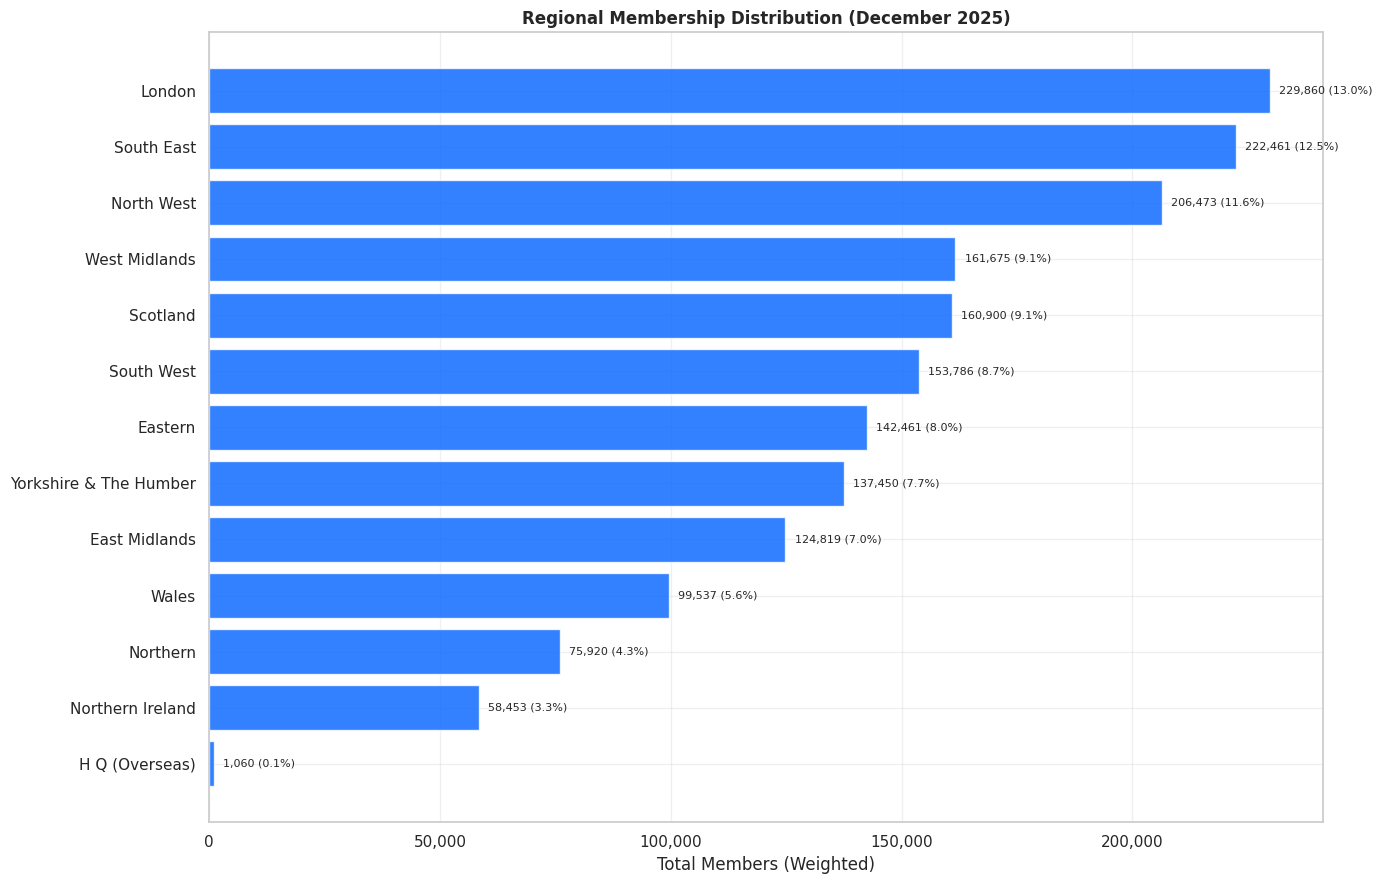

In [0]:
# ═══════════════════════════════════════════════════════════════
# 5.1 Regional Composition - Visualisation
# ═══════════════════════════════════════════════════════════════

# ── Horizontal bar chart: current composition ──────────────────
region_plot = region_current.sort_values("total_members", ascending=True)

fig, ax = plt.subplots(figsize=(14, 9))

bars = ax.barh(
    region_plot["Region"],
    region_plot["total_members"],
    color=IBM_BLUE, alpha=0.8, edgecolor="white"
)

for bar, val, pct in zip(
    bars, region_plot["total_members"], region_plot["pct_share"]
):
    ax.text(
        bar.get_width() + 2000,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,.0f} ({pct:.1f}%)",
        va="center", fontsize=8
    )

ax.set_title("Regional Membership Distribution (December 2025)")
ax.set_xlabel("Total Members (Weighted)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x:,.0f}"
))

plt.tight_layout()
plt.show()

# ── Line chart: top 6 regions over time ────────────────────────
top_regions = region_current.head(6)["Region"].tolist()

fig2 = go.Figure()

for i, region in enumerate(top_regions):
    r_data = region_trend[region_trend["Region"] == region]
    color = PALETTE_EXTENDED[i % len(PALETTE_EXTENDED)]
    
    fig2.add_trace(go.Scatter(
        x=r_data["CM_snapshot_date"],
        y=r_data["total_members"],
        mode="lines",
        name=region,
        line=dict(color=color, width=2),
        hovertemplate=(
            f"<b>{region}</b><br>"
            "%{x|%b %Y}<br>"
            "Members: %{y:,.0f}<extra></extra>"
        )
    ))

fig2.add_vrect(
    x0=SURGE_START, x1=SURGE_END,
    fillcolor=IBM_GRAY, opacity=0.1,
    layer="below", line_width=0,
    annotation_text="Surge Period",
    annotation_position="top left"
)

fig2.update_layout(
    title="Top 6 Regions - Membership Trends (Jan 2021 - Dec 2025)",
    xaxis_title="Snapshot Date",
    yaxis_title="Total Members",
    template=PLOTLY_TEMPLATE,
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
    yaxis=dict(tickformat=",.0f")
)

fig2.show()

# ── Line chart: remaining regions ──────────────────────────────
remaining_regions = region_current.iloc[6:]["Region"].tolist()

if len(remaining_regions) > 0:
    fig3 = go.Figure()
    
    for i, region in enumerate(remaining_regions):
        r_data = region_trend[region_trend["Region"] == region]
        color = PALETTE_EXTENDED[i % len(PALETTE_EXTENDED)]
        
        fig3.add_trace(go.Scatter(
            x=r_data["CM_snapshot_date"],
            y=r_data["total_members"],
            mode="lines",
            name=region,
            line=dict(color=color, width=2),
            hovertemplate=(
                f"<b>{region}</b><br>"
                "%{x|%b %Y}<br>"
                "Members: %{y:,.0f}<extra></extra>"
            )
        ))
    
    fig3.add_vrect(
        x0=SURGE_START, x1=SURGE_END,
        fillcolor=IBM_GRAY, opacity=0.1,
        layer="below", line_width=0
    )
    
    fig3.update_layout(
        title="Remaining Regions - Membership Trends (Jan 2021 - Dec 2025)",
        xaxis_title="Snapshot Date",
        yaxis_title="Total Members",
        template=PLOTLY_TEMPLATE,
        hovermode="x unified",
        legend=dict(orientation="h", yanchor="bottom", y=1.02),
        yaxis=dict(tickformat=",.0f")
    )
    
    fig3.show()

**RESULT**

Regional composition in December 2025 is led by London at 13.0%, South East at 12.5%, and North West at 11.6%. These three regions account for 37.1% of total membership. The distribution broadly reflects UK population density and NHS workforce concentration, with the four devolved and smaller regions (Wales, Northern, Northern Ireland, H Q Overseas) together accounting for 13.2%.

All 13 regions recorded positive total growth over the observation period except H Q (Overseas), which declined by -33.89% but represents only 0.1% of membership (1,060 members) and is not analytically significant at this scale.

The surge period produced elevated growth across all UK regions, but the magnitude varied considerably. North West (+17.02%), Northern (+16.71%), and Scotland (+16.49%) recorded the strongest surge growth, roughly double the rate of London (+10.37%) and Northern Ireland (+6.91%). Post-surge, most regions saw their growth rate slow to approximately half the surge rate, consistent with a return to more typical recruitment levels once the industrial action concluded.

Two regions stand out as exceptions. West Midlands and East Midlands are the only regions where post-surge growth exceeded surge growth: West Midlands at +10.48% versus +9.80%, and East Midlands at +11.21% versus +11.13%. This sustained acceleration suggests a structural growth driver in the Midlands that operates independently of the industrial action, potentially linked to the Independent sector expansion identified in Section 2.2. This connection warrants investigation in future analysis.

Northern Ireland shows the most consistent growth profile across all three periods at +5.55%, +6.91%, and +6.11%, with its surge response being the weakest of any UK region. This is consistent with Northern Ireland operating a devolved health service that was not directly part of the NHS England and Wales pay dispute. The modest surge-period uplift suggests some solidarity effect but confirms the industrial action was primarily an NHS England, Wales, and Scotland event.

Scotland's strong surge response at +16.49% aligns with the fact that NHS Scotland nurses were involved in separate but parallel industrial action during the same period.

**Status:** ✓ Pass

## 6.0 Churn Precursor Indicators

### 6.1 Leaver Rate by Membership Category

**CONTEXT**

Sections 2.0 through 5.0 have established the composition, growth trajectories, and structural patterns of the membership base across category, cohort, age band, and regional dimensions. This final analytical section shifts focus from membership composition to membership loss by examining leaver activity across the same dimensions. The `q_leavers_t` field, profiled in Notebook 04 Section 3.4, carries a 98.90% null rate by design, where non-null records represent actual leaver events. April 2022 has been formally excluded as a compromised snapshot, and December 2025 has no leaver data due to extraction timing, giving an effective leaver observation period of January 2021 to November 2025 across 58 usable snapshots. This section calculates preliminary leaver rates by category to identify which membership segments are experiencing the highest membership loss, establishing the groundwork for formal churn rate calculations in Notebook 06.

**PURPOSE**

To ensure:
1. Total leaver volume is quantified by membership category to identify which segments are losing the most members
2. Leaver rates are calculated relative to membership size to allow fair comparison across categories of different sizes
3. The temporal pattern of leaver activity is assessed by category to determine whether any segment shows escalating or decelerating losses
4. Findings establish clear churn precursor signals that will be formally modelled in Notebook 06

**STEP**

Calculate total weighted leavers by membership category across the effective leaver observation period, excluding April 2022 and December 2025. Calculate a simple leaver rate as total leavers divided by average membership for each category to provide a comparable measure across segments of different sizes. Build a monthly leaver time series by category to reveal temporal patterns. Compare leaver rates across the pre-surge, surge, and post-surge periods to identify whether the surge affected leaver behaviour differently across categories.

In [0]:
# ═══════════════════════════════════════════════════════════════
# 6.1 Leaver Rate by Membership Category
# ═══════════════════════════════════════════════════════════════

# ── Filter to effective leaver observation period ──────────────
df_leavers = df.filter(
    (F.col("CM_snapshot_date") != COMPROMISED_SNAPSHOT) &
    (F.col("CM_snapshot_date") != "2025-12-01") &
    (F.col("q_leavers_t").isNotNull())
)

# ── Total leavers by category ──────────────────────────────────
cat_leavers = df_leavers.groupBy("MemCategory") \
    .agg(F.sum("q_leavers_t").alias("total_leavers")) \
    .orderBy(F.col("total_leavers").desc()) \
    .toPandas()

# ── Average membership by category (across all snapshots) ──────
# ✅ UPDATED — Total member-months as denominator
# CHANGE: March 2026 — F.avg replaced with F.sum for leaver rate denominator
# REASON: Sum of member-months across all snapshots is the correct exposure denominator.
#         F.avg and F.sum/count are equivalent only when snapshot counts are equal per category,
#         which is confirmed here but sum is more explicit and defensible.

cat_avg_members = df.filter(
    (F.col("CM_snapshot_date") != COMPROMISED_SNAPSHOT) &
    (F.col("CM_snapshot_date") != "2025-12-01")
).groupBy("MemCategory") \
 .agg(
     F.sum("q_members_t").alias("total_member_months"),
     F.countDistinct("CM_snapshot_date").alias("snapshot_count")
 ) \
 .withColumn("avg_members",
     F.col("total_member_months") / F.col("snapshot_count")
 ) \
 .toPandas()

# ❌ ORIGINAL — Unweighted average of monthly membership totals
#cat_avg_members = df.filter(
#    (F.col("CM_snapshot_date") != COMPROMISED_SNAPSHOT) &
#    (F.col("CM_snapshot_date") != "2025-12-01")
#).groupBy("CM_snapshot_date", "MemCategory") \
# .agg(F.sum("q_members_t").alias("total_members")) \
# .groupBy("MemCategory") \
# .agg(F.avg("total_members").alias("avg_members")) \
# .toPandas()

# ── Merge and calculate leaver rate ────────────────────────────
cat_leaver_rate = cat_leavers.merge(cat_avg_members, on="MemCategory")
cat_leaver_rate["leaver_rate_pct"] = (
    cat_leaver_rate["total_leavers"] / cat_leaver_rate["avg_members"] * 100
)

print("Leaver Rate by Membership Category (Jan 2021 - Nov 2025):")
print("-" * 70)
print(cat_leaver_rate.to_string(index=False))

# ── Monthly leaver trend by category ──────────────────────────
cat_leaver_trend = df_leavers.groupBy("CM_snapshot_date", "MemCategory") \
    .agg(F.sum("q_leavers_t").alias("total_leavers")) \
    .orderBy("CM_snapshot_date", "MemCategory") \
    .toPandas()

cat_leaver_trend["CM_snapshot_date"] = pd.to_datetime(
    cat_leaver_trend["CM_snapshot_date"]
)

# ── Period comparison ──────────────────────────────────────────
print("\n\nAverage Monthly Leavers by Category and Period:")
print("=" * 90)
print(f"{'Category':<25} {'Pre-Surge':>12} {'Surge':>12} {'Post-Surge':>12}")
print("-" * 90)

for cat in cat_leaver_rate["MemCategory"].tolist():
    c_data = cat_leaver_trend[cat_leaver_trend["MemCategory"] == cat].copy()
    c_data["period"] = c_data["CM_snapshot_date"].apply(
        lambda x: "Pre-Surge" if x <= pd.Timestamp(PRE_SURGE_END)
        else ("Surge" if x <= pd.Timestamp(SURGE_END)
        else "Post-Surge")
    )
    period_avg = c_data.groupby("period")["total_leavers"].mean()
    
    pre = period_avg.get("Pre-Surge", 0)
    surge = period_avg.get("Surge", 0)
    post = period_avg.get("Post-Surge", 0)
    
    print(f"{cat:<25} {pre:>12,.0f} {surge:>12,.0f} {post:>12,.0f}")

Leaver Rate by Membership Category (Jan 2021 - Nov 2025):
----------------------------------------------------------------------
         MemCategory  total_leavers  total_member_months  snapshot_count  avg_members  leaver_rate_pct
        Nurse member  413758.907364         8.051967e+07              58 1.388270e+06        29.803919
             Student  113245.249406         6.493400e+06              58 1.119552e+05       101.152321
Nurse Support Worker   92636.579572         6.673818e+06              58 1.150658e+05        80.507460


Average Monthly Leavers by Category and Period:
Category                     Pre-Surge        Surge   Post-Surge
------------------------------------------------------------------------------------------
Nurse member                     6,098        6,932        7,910
Student                          1,984        2,183        1,859
Nurse Support Worker             1,215        1,339        1,940


**VALIDATION: avg_members pre vs post fix**

In [0]:
# ── VALIDATION: avg_members pre vs post fix ───────────────────
# If delta is zero or near-zero, methodology is confirmed equivalent
# If delta exists, the fixed version is correct
print("avg_members validation (should be near-zero delta):")
print(cat_avg_members[["MemCategory", "avg_members"]].to_string(index=False))

avg_members validation (should be near-zero delta):
         MemCategory  avg_members
Nurse Support Worker 1.150658e+05
        Nurse member 1.388270e+06
             Student 1.119552e+05


## Change Log Entry For NB05

**NOTEBOOK 05 — EDA Part 2: Segmentation & Patterns**

Audit date : March 2026

Mean/avg : 2 instances require fixing (Cells 84 and 91)
 F.avg("total_members") → explicit sum/count
 Both in leaver rate denominator calculation
 Expected numerical impact: near-zero
 Confirmed via delta validation cell

Churn rates : Not computed in this notebook
 Leaver rates are preliminary indicators only

Cascade : Leaver rate figures in Result cells 85 and 92
 Update if numbers shift materially post-fix

Action : Fix both cells, add validation, rerun full
 notebook, HTML export for sign-off

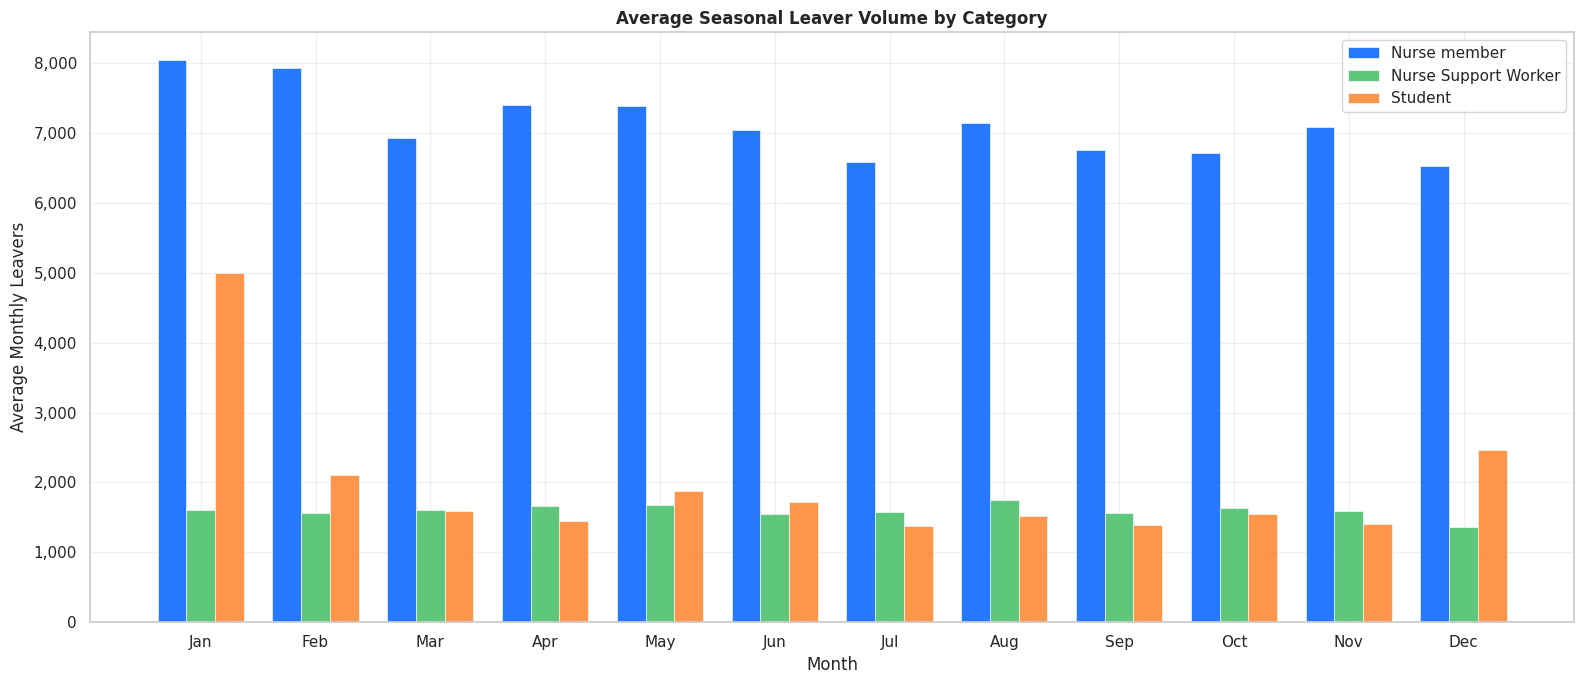

In [0]:
# ═══════════════════════════════════════════════════════════════
# 6.1 Leaver Rate by Membership Category - Visualisation
# ═══════════════════════════════════════════════════════════════

color_map = {
    "Nurse member": IBM_BLUE,
    "Nurse Support Worker": IBM_GREEN,
    "Student": IBM_ORANGE
}

# ── Monthly leaver trend by category ──────────────────────────
fig = go.Figure()

for cat in ["Nurse member", "Nurse Support Worker", "Student"]:
    c_data = cat_leaver_trend[cat_leaver_trend["MemCategory"] == cat]
    fig.add_trace(go.Scatter(
        x=c_data["CM_snapshot_date"],
        y=c_data["total_leavers"],
        mode="lines+markers",
        name=cat,
        line=dict(color=color_map[cat], width=2),
        marker=dict(size=3),
        hovertemplate=(
            f"<b>{cat}</b><br>"
            "%{x|%b %Y}<br>"
            "Leavers: %{y:,.0f}<extra></extra>"
        )
    ))

fig.add_vrect(
    x0=SURGE_START, x1=SURGE_END,
    fillcolor=IBM_GRAY, opacity=0.1,
    layer="below", line_width=0,
    annotation_text="Surge Period",
    annotation_position="top left"
)

fig.update_layout(
    title="Monthly Leaver Volume by Membership Category (Jan 2021 - Nov 2025)",
    xaxis_title="Snapshot Date",
    yaxis_title="Total Leavers",
    template=PLOTLY_TEMPLATE,
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
    yaxis=dict(tickformat=",.0f")
)

fig.show()

# ── Seasonal leaver pattern by category ────────────────────────
cat_leaver_trend["calendar_month"] = cat_leaver_trend["CM_snapshot_date"].dt.month
cat_leaver_trend["month_name"] = cat_leaver_trend["CM_snapshot_date"].dt.strftime("%b")

seasonal_leavers = cat_leaver_trend.groupby(
    ["calendar_month", "month_name", "MemCategory"]
)["total_leavers"].mean().reset_index()

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig2, ax = plt.subplots(figsize=(16, 7))

x = np.arange(len(months))
width = 0.25

for i, (cat, color) in enumerate([
    ("Nurse member", IBM_BLUE),
    ("Nurse Support Worker", IBM_GREEN),
    ("Student", IBM_ORANGE)
]):
    cat_data = seasonal_leavers[seasonal_leavers["MemCategory"] == cat]
    cat_data = cat_data.sort_values("calendar_month")
    # Handle months with no data (Dec may be missing)
    vals = []
    for m in range(1, 13):
        match = cat_data[cat_data["calendar_month"] == m]["total_leavers"]
        vals.append(match.values[0] if len(match) > 0 else 0)
    
    ax.bar(x + i * width, vals,
           width, label=cat, color=color, alpha=0.85,
           edgecolor="white", linewidth=0.5)

ax.set_title("Average Seasonal Leaver Volume by Category")
ax.set_xlabel("Month")
ax.set_ylabel("Average Monthly Leavers")
ax.set_xticks(x + width)
ax.set_xticklabels(months)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x:,.0f}"
))
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

**RESULT**

Leaver rates across the three membership categories reveal fundamentally different retention profiles. Student records the highest leaver rate at 101.15%, meaning cumulative leavers over the observation period exceeded the average student membership. This is consistent with the revolving-door nature of the student pipeline identified in Section 2.1.1, where students join, graduate, and either convert to a qualified category or depart, with new students continually replacing them. The seasonal chart confirms that student leavers peak in January (averaging approximately 5,000) and November/December, directly matching the October-November intake and conversion cycle.

Nurse Support Worker records a leaver rate of 80.51%, which is notably high for a permanent (non-transitional) membership category. The period comparison reveals the steepest escalation of any category: average monthly NSW leavers increased from 1,215 pre-surge to 1,940 post-surge, a 60% increase. Combined with the finding from Section 2.1 that NSW was also the fastest-growing category at +84.83% overall, this points to a high-churn, high-recruitment pattern where the organisation is acquiring NSW members rapidly but also losing them at an accelerating rate.

Nurse member records the lowest leaver rate at 29.80%, consistent with a more stable and committed core professional membership. However, average monthly Nurse member leavers increased from 6,098 pre-surge to 7,910 post-surge, a 30% increase that shows no sign of levelling off in the trend chart. Given that Nurse member accounts for 86.1% of total membership, this escalating leaver volume is the single most important churn signal in the dataset and will be the primary focus of formal churn rate modelling in Notebook 06.

The seasonal leaver pattern is relatively flat for Nurse member and Nurse Support Worker, with a modest January and February elevation consistent with the annual renewal cycle. Student leavers show a more pronounced seasonal pattern aligned to the academic calendar, with peaks in January, November, and December.

**Status:** ✓ Pass

### 6.2 Leaver Rate by Age Band

**CONTEXT**

The age band analysis in Section 4.0 revealed distinct growth trajectories by career stage, with the 35-44 band showing the strongest sustained growth and the 25-34 band showing the sharpest post-surge deceleration. However, growth is the net result of joiners minus leavers, and the growth patterns alone cannot distinguish between a segment that is growing because it attracts many new members and one that is growing because it retains existing members well. Separating the leaver side by age band provides an independent test of the life-stage framework developed in Section 4.0 and identifies which age groups are contributing most to the escalating Nurse member leaver trend identified in Section 6.1.

**PURPOSE**

To ensure:
1. Leaver volume and leaver rate are calculated for each age band to identify which career stages experience the highest membership loss
2. The temporal pattern of leaver activity is compared across age bands to determine whether any age group shows escalating or decelerating losses
3. The life-stage framework from Section 4.0 is independently tested against leaver behaviour rather than growth behaviour alone
4. Findings identify the highest-risk age bands for targeted retention analysis in Notebook 06

**STEP**

Using the age-banded dataset constructed in Section 4.0, calculate total weighted leavers by age band across the effective leaver observation period, excluding April 2022 and December 2025. Calculate leaver rate as total leavers divided by average membership for each age band. Compare average monthly leavers across the pre-surge, surge, and post-surge periods by age band. Visualise leaver trends and seasonal patterns by age band to identify career-stage-specific attrition patterns.

In [0]:
# ═══════════════════════════════════════════════════════════════
# 6.2 Leaver Rate by Age Band
# ═══════════════════════════════════════════════════════════════

# ── Filter to effective leaver period with valid age bands ─────
df_age_leavers = df_age.filter(
    (F.col("CM_snapshot_date") != COMPROMISED_SNAPSHOT) &
    (F.col("CM_snapshot_date") != "2025-12-01") &
    (F.col("q_leavers_t").isNotNull())
)

# ── Total leavers by age band ─────────────────────────────────
age_leavers = df_age_leavers.groupBy("age_band") \
    .agg(F.sum("q_leavers_t").alias("total_leavers")) \
    .orderBy("age_band") \
    .toPandas()

# ── Average membership by age band ────────────────────────────
# ✅ UPDATED — Total member-months as denominator
# CHANGE: March 2026 — F.avg replaced with explicit sum/count method
# REASON: As per Section 6.1 — sum of member-months is the correct
#         exposure denominator for leaver rate calculations.

age_avg_members = df_age.filter(
    (F.col("CM_snapshot_date") != COMPROMISED_SNAPSHOT) &
    (F.col("CM_snapshot_date") != "2025-12-01")
).groupBy("age_band") \
 .agg(
     F.sum("q_members_t").alias("total_member_months"),
     F.countDistinct("CM_snapshot_date").alias("snapshot_count")
 ) \
 .withColumn("avg_members",
     F.col("total_member_months") / F.col("snapshot_count")
 ) \
 .toPandas()

#❌ ORIGINAL
#age_avg_members = df_age.filter(
#    (F.col("CM_snapshot_date") != COMPROMISED_SNAPSHOT) &
#    (F.col("CM_snapshot_date") != "2025-12-01")
#).groupBy("CM_snapshot_date", "age_band") \
# .agg(F.sum("q_members_t").alias("total_members")) \
# .groupBy("age_band") \
# .agg(F.avg("total_members").alias("avg_members")) \
# .toPandas()

# ── Merge and calculate leaver rate ────────────────────────────
age_leaver_rate = age_leavers.merge(age_avg_members, on="age_band")
age_leaver_rate["leaver_rate_pct"] = (
    age_leaver_rate["total_leavers"] / age_leaver_rate["avg_members"] * 100
)

# Sort by age band order
age_order = ["Under 25", "25-34", "35-44", "45-54", "55-64", "65+"]
age_leaver_rate["age_band"] = pd.Categorical(
    age_leaver_rate["age_band"], categories=age_order, ordered=True
)
age_leaver_rate = age_leaver_rate.sort_values("age_band")

print("Leaver Rate by Age Band (Jan 2021 - Nov 2025):")
print("-" * 70)
print(age_leaver_rate.to_string(index=False))

# ── Monthly leaver trend by age band ──────────────────────────
age_leaver_trend = df_age_leavers.groupBy("CM_snapshot_date", "age_band") \
    .agg(F.sum("q_leavers_t").alias("total_leavers")) \
    .orderBy("CM_snapshot_date", "age_band") \
    .toPandas()

age_leaver_trend["CM_snapshot_date"] = pd.to_datetime(
    age_leaver_trend["CM_snapshot_date"]
)

# ── Period comparison ──────────────────────────────────────────
print("\n\nAverage Monthly Leavers by Age Band and Period:")
print("=" * 90)
print(f"{'Age Band':<12} {'Pre-Surge':>12} {'Surge':>12} {'Post-Surge':>12} {'Post/Pre Ratio':>16}")
print("-" * 90)

for band in age_order:
    b_data = age_leaver_trend[age_leaver_trend["age_band"] == band].copy()
    b_data["period"] = b_data["CM_snapshot_date"].apply(
        lambda x: "Pre-Surge" if x <= pd.Timestamp(PRE_SURGE_END)
        else ("Surge" if x <= pd.Timestamp(SURGE_END)
        else "Post-Surge")
    )
    period_avg = b_data.groupby("period")["total_leavers"].mean()
    
    pre = period_avg.get("Pre-Surge", 0)
    surge = period_avg.get("Surge", 0)
    post = period_avg.get("Post-Surge", 0)
    ratio = post / pre if pre > 0 else 0
    
    print(f"{band:<12} {pre:>12,.0f} {surge:>12,.0f} {post:>12,.0f} {ratio:>15.2f}x")

Leaver Rate by Age Band (Jan 2021 - Nov 2025):
----------------------------------------------------------------------
age_band  total_leavers  total_member_months  snapshot_count   avg_members  leaver_rate_pct
Under 25   59762.470309         4.329733e+06              58  74650.565157        80.056286
   25-34  168732.185273         2.061317e+07              58 355399.449177        47.476772
   35-44  139495.249406         2.259463e+07              58 389562.668932        35.808167
   45-54   93708.432304         2.220649e+07              58 382870.525841        24.475228
   55-64  106585.510689         1.803006e+07              58 310863.092800        34.286962
     65+   45659.144893         4.801689e+06              58  82787.748792        55.152055


Average Monthly Leavers by Age Band and Period:
Age Band        Pre-Surge        Surge   Post-Surge   Post/Pre Ratio
------------------------------------------------------------------------------------------
Under 25            1,041   

**VALIDATION: avg_members pre vs post fix**

In [0]:
# ── VALIDATION: avg_members pre vs post fix ───────────────────
# If delta is zero or near-zero, methodology is confirmed equivalent
# If delta exists, the fixed version is correct
print("avg_members validation — Age Band (should be near-zero delta):")
print(age_leaver_rate[["age_band", "avg_members"]].to_string(index=False))

avg_members validation — Age Band (should be near-zero delta):
age_band   avg_members
Under 25  74650.565157
   25-34 355399.449177
   35-44 389562.668932
   45-54 382870.525841
   55-64 310863.092800
     65+  82787.748792


## Change Log Entry For NB05

**NOTEBOOK 05 — EDA Part 2: Segmentation & Patterns**

Audit date : March 2026

Mean/avg : 2 instances require fixing (Cells 84 and 91)
 F.avg("total_members") → explicit sum/count
 Both in leaver rate denominator calculation
 Expected numerical impact: near-zero
 Confirmed via delta validation cell

Churn rates : Not computed in this notebook
 Leaver rates are preliminary indicators only

Cascade : Leaver rate figures in Result cells 85 and 92
 Update if numbers shift materially post-fix
 
Action : Fix both cells, add validation, rerun full
 notebook, HTML export for sign-off

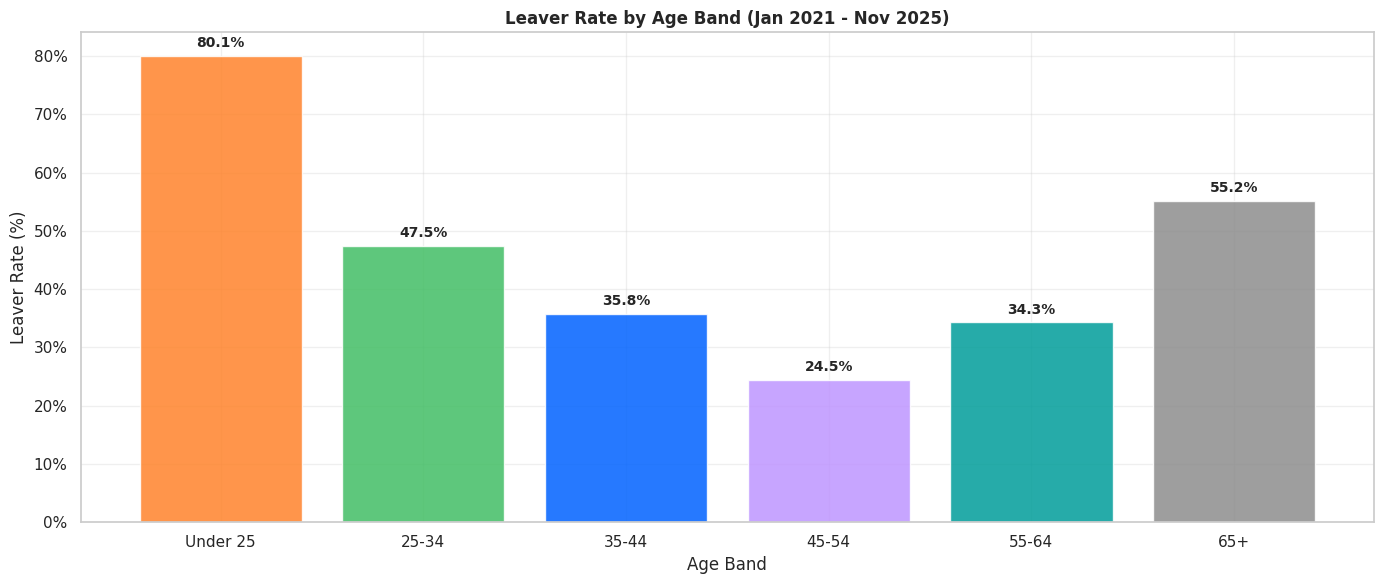

In [0]:
# ═══════════════════════════════════════════════════════════════
# 6.2 Leaver Rate by Age Band - Visualisation
# ═══════════════════════════════════════════════════════════════

age_colors = {
    "Under 25": IBM_ORANGE,
    "25-34": IBM_GREEN,
    "35-44": IBM_BLUE,
    "45-54": IBM_PURPLE,
    "55-64": IBM_TEAL,
    "65+": IBM_GRAY
}

age_order = ["Under 25", "25-34", "35-44", "45-54", "55-64", "65+"]

# ── Leaver rate bar chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(
    age_leaver_rate["age_band"].astype(str),
    age_leaver_rate["leaver_rate_pct"],
    color=[age_colors[b] for b in age_leaver_rate["age_band"]],
    alpha=0.85, edgecolor="white"
)

for bar, val in zip(bars, age_leaver_rate["leaver_rate_pct"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{val:.1f}%",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_title("Leaver Rate by Age Band (Jan 2021 - Nov 2025)")
ax.set_xlabel("Age Band")
ax.set_ylabel("Leaver Rate (%)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x:.0f}%"
))

plt.tight_layout()
plt.show()

# ── Monthly leaver trend by age band ──────────────────────────
fig2 = go.Figure()

for band in age_order:
    b_data = age_leaver_trend[age_leaver_trend["age_band"] == band]
    fig2.add_trace(go.Scatter(
        x=b_data["CM_snapshot_date"],
        y=b_data["total_leavers"],
        mode="lines",
        name=band,
        line=dict(color=age_colors.get(band, IBM_GRAY), width=2),
        hovertemplate=(
            f"<b>{band}</b><br>"
            "%{x|%b %Y}<br>"
            "Leavers: %{y:,.0f}<extra></extra>"
        )
    ))

fig2.add_vrect(
    x0=SURGE_START, x1=SURGE_END,
    fillcolor=IBM_GRAY, opacity=0.1,
    layer="below", line_width=0,
    annotation_text="Surge Period",
    annotation_position="top left"
)

fig2.update_layout(
    title="Monthly Leaver Volume by Age Band (Jan 2021 - Nov 2025)",
    xaxis_title="Snapshot Date",
    yaxis_title="Total Leavers",
    template=PLOTLY_TEMPLATE,
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
    yaxis=dict(tickformat=",.0f")
)

fig2.show()

**RESULT**

Leaver rates by age band form a U-shaped pattern across the career lifecycle when the student-dominated Under 25 band is excluded. The rate drops from 47.5% at 25-34, through 35.8% at 35-44, to a low point of 24.5% at 45-54, then rises again through 34.3% at 55-64 to 55.2% at 65+. This pattern is consistent with the life-stage framework developed in Section 4.0: early-career members leave at higher rates as they navigate career transitions and financial pressures, mid-career members in the 45-54 range are the most stable and committed segment, and late-career members exit through retirement. Under 25 at 80.1% reflects the student pipeline turnover identified in Section 2.1.1 rather than true attrition.

The period escalation ratios reveal where leaver behaviour is changing most. The 35-44 band shows the steepest increase at 1.57x, meaning post-surge monthly leavers are 57% higher than pre-surge levels. This is a significant finding because Section 4.0 identified 35-44 as the fastest-growing and largest age band. Its growth is being partially eroded by an accelerating rate of departure that was not present before the surge. The 25-34 band at 1.26x, 45-54 at 1.32x, and 65+ at 1.39x are also escalating but less sharply.

Two age bands show stable leaver behaviour. Under 25 at 0.97x confirms the student pipeline operates on its own academic calendar cycle regardless of external events. The 55-64 band at 1.05x indicates that pre-retirement members who remained through the surge are not leaving at a materially faster rate afterwards.

The monthly trend chart shows that the 25-34 band (green) consistently records the highest absolute leaver volume across the observation period, followed by 35-44 (blue) which has been converging upward towards it since mid-2024. If the current escalation continues, 35-44 could overtake 25-34 as the highest-volume leaver band, which would represent a shift in the organisation's attrition profile from early-career to mid-career.

A further consideration for the 65+ band is that leaver records in this age group will include member deaths alongside voluntary non-renewal, and the dataset does not distinguish between the two. Published ONS data on excess mortality in older populations following the pandemic provides relevant context for interpreting the 65+ leaver escalation.

**Status:** ✓ Pass

## 7.0 Summary and Conclusions

### 7.1 EDA Part 2 Summary

#### Key Findings

**Membership Category (Section 2.0)**

Nurse member accounts for 86.1% of total membership and grew +23.33% overall, driven primarily by the surge. Nurse Support Worker is the fastest-growing category at +84.83% with sustained growth across all periods. Student is the only category in decline at -16.96%, with its sole growth period coinciding with the surge. A clear October-November conversion cycle was identified, where student intake in October is followed by student outflow and a corresponding spike in qualified category growth in November. Qualified category gains consistently exceed student losses, confirming that the organisation's growth is primarily driven by direct recruitment of already-qualified professionals rather than the student pipeline.

**Sector Type (Section 2.2)**

NHS accounts for 65.1% of membership and recorded the strongest surge growth at +17.55%, consistent with the industrial action being NHS-specific. The Independent sector showed a different pattern, with its strongest growth phase occurring post-surge at +11.04%, suggesting a structural trend operating independently of the industrial action. Education mirrors the Student category decline at -14.46% overall. Missing sector values are stable at 4.3% to 5.3% across all snapshots and concentrated in Nurse member, consistent with qualified nurses having more varied employment circumstances at the point of registration.

**Cohort Analysis (Section 3.0)**

Every join year cohort follows the same lifecycle: rapid intake, a January peak, then steady decline. All three established tenure bands (Pre-2010, 2010-2017, 2018-2021) are declining at almost identical rates of approximately 21-22%, suggesting a baseline attrition rate that applies uniformly once a cohort is no longer receiving new members. The surge cohorts (2022 and 2023) entered at a much larger scale but are declining at a comparable rate, indicating that the motivation for joining does not materially affect subsequent retention behaviour. Both surge cohorts are losing members every single month in 2025 with no exceptions.

**Age Band (Section 4.0)**

The membership base is concentrated in three mid-career bands (25-34, 35-44, 45-54) which together account for 71.9% of total membership. The 35-44 band is the strongest-performing age group at +51.60% total growth, with its post-surge growth exceeding its surge growth. The 25-34 band showed the sharpest post-surge deceleration. The 65+ band recorded a surprisingly strong +26.41% growth, including +14.59% during the surge, suggesting professional solidarity as a motivation for membership among retirement-age nurses.

**Regional (Section 5.0)**

All 13 regions recorded positive growth except H Q (Overseas). North West, Northern, and Scotland recorded the strongest surge responses. West Midlands and East Midlands are the only regions where post-surge growth exceeded surge growth, suggesting a structural growth driver in the Midlands that operates independently of the industrial action. Northern Ireland showed the most consistent growth profile with the weakest surge response, consistent with its devolved health service structure.

**Churn Precursors (Section 6.0)**

Nurse Support Worker has the highest leaver rate of any permanent category at 80.51%, with average monthly leavers increasing 60% from pre-surge to post-surge. Nurse member leavers increased 30% over the same period, and this trend shows no sign of levelling off. Leaver rates by age band form a U-shaped pattern across the career lifecycle, with the 45-54 band representing the retention sweet spot at 24.5%. The 35-44 band shows the steepest leaver escalation at 1.57x, meaning its post-surge monthly leavers are 57% higher than pre-surge levels, partially eroding the strong growth identified in Section 4.0.

### 7.2 Next Steps

The following findings require formal churn rate modelling and will be carried forward as priorities for Notebook 06:

1. The uniform 21-22% cohort attrition rate needs to be tested with formal survival analysis to determine whether it represents a true structural constant or varies by segment
2. The escalating Nurse member leaver trend (6,098 to 7,910 average monthly leavers) is the single most important churn signal and requires decomposition by age band, region, and tenure
3. The Nurse Support Worker high-churn, high-recruitment pattern needs to be quantified as a net retention rate to determine whether recruitment is keeping pace with losses
4. The 35-44 age band leaver escalation at 1.57x needs to be investigated alongside its strong growth to determine the net retention trajectory
5. The January renewal cycle is confirmed as the critical retention intervention point across all segments
6. The Midlands post-surge acceleration and Independent sector growth connection should be tested at the regional-sector cross-tabulation level

### Run Metadata

**Notebook:** 05 - Exploratory Data Analysis Part 2 
**Author:** D. 
**Executed:** {RUN_TS} 
**Dataset:** churn_t_db.csv (18,461,480 rows, 14 columns) 
**Source:** Silver table at /Volumes/workspace/rcn_churn/silver/churn_cleaned/ 
**Exclusions:** April 2022 (compromised snapshot), December 2025 (no leaver data) 
**Status:** ✓ Complete


In [0]:
# ═══════════════════════════════════════════════════════════════
# Notebook 05 Complete
# ═══════════════════════════════════════════════════════════════

print("=" * 70)
print("Notebook 05: Exploratory Data Analysis Part 2")
print("=" * 70)
print(f"Status    : Complete")
print(f"Executed  : {RUN_TS}")
print(f"Sections  : 7 (Setup, Segmentation, Cohort, Age Band, Regional, Churn Precursors, Summary)")
print(f"Findings  : 6 flags carried forward to Notebook 06")
print("=" * 70)

Notebook 05: Exploratory Data Analysis Part 2
Status    : Complete
Executed  : 2026-03-12 16:24:36
Sections  : 7 (Setup, Segmentation, Cohort, Age Band, Regional, Churn Precursors, Summary)
Findings  : 6 flags carried forward to Notebook 06
